# Media Source Extraction Pipeline

```
Setup & data load
  → Step 1:  Split cells into individual source candidates
  → Step 2:  Clean each string
  → Step 3:  Frequency table + distribution chart (visualise how many sources vs how many mentions)
  → Step 4:  Extract frequent names (>3 mentions) from long sentences → new freq table + chart
  → Step 5:  Social-media column audit — what did people write in Facebook/Instagram/etc?
  → Step 6:  Unification — all hardcoded dictionaries (MM + SM aliases, noise filter, normalisation) applied to ALL sources
  → Step 7:  Frequency table after unification + distribution chart
  → Step 8:  Categorisation of all unified sources
```


# Setup and data load

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

df = pd.read_csv('media_sources_internship.csv')
print(df.shape)
print(list(df.columns))

(928, 21)
['PROLIFIC_PID', 'Facebook', 'Facebook_freq', 'Instagram', 'Instagram_freq', 'TV news programs', 'TV news programs_freq', 'TikTok', 'TikTok_freq', 'Twitter/X', 'Twitter/X_freq', 'YouTube', 'YouTube_freq', 'online news sites', 'online news sites_freq', 'podcasts', 'podcasts_freq', 'printed newspapers', 'printed newspapers_freq', 'the radio', 'the radio_freq']


In [3]:
# Survey columns where the platform itself is social media
SM_SURVEY_COLS = ['Facebook', 'Instagram', 'TikTok', 'Twitter/X', 'YouTube']

# Survey columns for traditional media
MM_SURVEY_COLS = ['TV news programs', 'online news sites', 'podcasts',
                  'printed newspapers', 'the radio']

# All free-text columns (drop ID and pre-aggregated freq columns)
source_cols = [c for c in df.columns
               if not c.endswith('_freq') and c != 'PROLIFIC_PID']

# Stack into one long Series, keep track of which column each entry came from
all_text_with_col = (
    df[source_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'survey_col', 0: 'text'})
    .assign(text=lambda d: d['text'].astype(str))
)
all_text = all_text_with_col['text']
print(f"Total cells: {len(all_text)}")

Total cells: 2771


# Step 1: Split cells into individual source candidates

Cells contain multiple sources separated by commas, semicolons, newlines, or 'and'.
'and' is tricky — only split on it when the text to the left is ≤30 chars (likely a short name, not a sentence).
Sources whose names contain 'and' go in PROTECTED_NAMES — never split those.

In [4]:
PROTECTED_NAMES = {
    'aba and preach',
    'faith and freedom coalition',
    'guns and butter',
    'law and crime',
    'crime and justice',
    'meet the press',
    'msnbc',  # kept separate — 'meet the press' is a program, 'msnbc' is a channel
    'breaking points with krystal and saagar',
}

def split_sources(text):
    # Split on clear delimiters — never part of a source name
    segs = re.split(r'[;,\n:/]|\.\.\.+', text)
    result = []
    for seg in segs:
        if seg.strip().lower() in PROTECTED_NAMES:
            result.append(seg)
            continue
        parts = re.split(r'\s+and\s+', seg, flags=re.IGNORECASE)
        if len(parts) == 1:
            result.append(seg)
        else:
            current = parts[0]
            for nxt in parts[1:]:
                if len(current.strip()) <= 30:
                    # Short left side → 'and' is a list separator, e.g. 'CNN and BBC'
                    result.append(current)
                    current = nxt
                else:
                    # Long left side → 'and' is part of the text, keep together
                    current = current + ' and ' + nxt
            result.append(current)
    return [s.strip() for s in result if s.strip()]
 

# Step 2: Clean each candidate string

Lowercase, strip URLs, remove domain endings, remove noise punctuation.
Also record which survey column the entry came from — needed later for MM-in-SM detection.

In [5]:
def clean(s):
    s = s.lower()
    s = re.sub(r'https?://|www\.|//', '', s)
    # .co.uk before .co so we catch the full thing
    s = re.sub(r'\.co\.uk|\.com|\.org|\.net|\.co|\.uk|\.gov|\.edu', '', s)
    s = s.replace('_', ' ')
    s = re.sub(r'[@™\'\"()\[\]]', '', s)
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.strip(' /-.')
    return s

# Explode: one row per split+cleaned piece, keeping survey_col
rows = []
for _, row in all_text_with_col.iterrows():
    for piece in split_sources(row['text']):
        c = clean(piece)
        if c:
            rows.append({
                'cleaned':    c,
                'survey_col': row['survey_col'],
                'col_type':   'SM_col' if row['survey_col'] in SM_SURVEY_COLS else 'MM_col',
            })

exploded = pd.DataFrame(rows)
all_cleaned = exploded['cleaned']

print(f"Total mentions (with repeats): {len(all_cleaned)}")
print(f"Unique strings: {all_cleaned.nunique()}")

Total mentions (with repeats): 6355
Unique strings: 2506


# Step 3: Frequency table

Count how often each unique string appears.
We focus on strings mentioned >3 times — these are the ones worth spending effort on.

In [6]:
# Frequency table based on MENTIONS (one respondent writing CNN in 2 columns = 2)
freq = all_cleaned.value_counts().reset_index()
freq.columns = ['source', 'count']
freq['cumulative_pct'] = (freq['count'].cumsum() / freq['count'].sum() * 100).round(1)

top = freq[freq['count'] > 3].copy()
print(f"Strings mentioned more than 3 times: {len(top)}")
print(f"These cover {top['count'].sum()} of {len(all_cleaned)} total mentions "
      f"({top['count'].sum()/len(all_cleaned)*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top.to_string())

# Frequency table based on UNIQUE RESPONDENTS
# (CNN written by same person in Facebook + Instagram = counted once)
respondent_source = (
    exploded[['survey_col', 'cleaned']]
    .copy()
    .assign(respondent_id=lambda d: exploded.index // len(source_cols))
)
# Use the original df index to get respondent — exploded was built row-by-row over df
# Attach respondent id from the original df row
rows_with_pid = []
for df_idx, row in df.iterrows():
    for col in source_cols:
        val = str(row[col])
        for piece in split_sources(val):
            c = clean(piece)
            if c:
                rows_with_pid.append({'cleaned': c, 'respondent_id': df_idx})

exploded_with_pid = pd.DataFrame(rows_with_pid)

# Per respondent: deduplicate sources
unique_per_resp = exploded_with_pid.drop_duplicates(subset=['respondent_id', 'cleaned'])
freq_unique = unique_per_resp['cleaned'].value_counts().reset_index()
freq_unique.columns = ['source', 'unique_respondents']

top_unique = freq_unique[freq_unique['unique_respondents'] > 3].copy()

print(f"\nUnique-respondent table: strings mentioned by >3 unique respondents: {len(top_unique)}")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unique.head(40).to_string())

# Comparison: mention-based vs respondent-based top lists
top_sources_mentions = set(top['source'])
top_sources_unique   = set(top_unique['source'])
overlap = top_sources_mentions & top_sources_unique
only_mentions = top_sources_mentions - top_sources_unique
only_unique   = top_sources_unique - top_sources_mentions

print(f"\nComparison (>3 threshold):")
print(f"  Based on mentions:            {len(top_sources_mentions)} sources")
print(f"  Based on unique respondents:  {len(top_sources_unique)} sources")
print(f"  Overlap (in both):            {len(overlap)} sources")
print(f"  Only in mention-based:        {len(only_mentions)} — {sorted(only_mentions)[:10]}")
print(f"  Only in respondent-based:     {len(only_unique)}  — {sorted(only_unique)[:10]}")
print(f"\nOverlap % of mention-based: {len(overlap)/len(top_sources_mentions)*100:.1f}%")

# Check what % of frequent words are mainstream media (in ALIAS_MAP targets)
import re as _re
ALIAS_TARGETS = set(v for _, v in [
    ('cnn','CNN'),('fox news','Fox News'),('msnbc','MSNBC'),('abc news','ABC News'),
    ('nbc news','NBC News'),('cbs news','CBS News'),('bbc news','BBC News'),
    ('npr','NPR'),('new york times','New York Times'),('washington post','Washington Post'),
    ('wall street journal','Wall Street Journal'),('reuters','Reuters'),
    ('associated press','Associated Press'),('pbs newshour','PBS NewsHour'),
    ('al jazeera','Al Jazeera'),('cnbc','CNBC'),('usa today','USA Today'),
])
mention_mm = {s for s in top_sources_mentions if s in ALIAS_TARGETS or
              any(s == v for _,v in [('cnn','CNN')])}
# simpler: check by unifying and seeing if they map to known MM
print(f"\nNote: check categories after Step 6 to see what % of frequent words are mainstream media.")

# Unique-respondent frequency table
# One respondent writing CNN in both Facebook and Instagram counts as 1, not 2.
# We build this by attaching the original df row index (= respondent) to each entry.
rows_with_pid = []
for df_idx, row in df.iterrows():
    for col in source_cols:
        val = str(row[col])
        for piece in split_sources(val):
            c = clean(piece)
            if c:
                rows_with_pid.append({'cleaned': c, 'respondent_id': df_idx})

exploded_with_pid = pd.DataFrame(rows_with_pid)

# Drop duplicate (respondent, source) pairs — same source by same person counts once
unique_per_resp = exploded_with_pid.drop_duplicates(subset=['respondent_id', 'cleaned'])
freq_unique = unique_per_resp['cleaned'].value_counts().reset_index()
freq_unique.columns = ['source', 'unique_respondents']

top_unique = freq_unique[freq_unique['unique_respondents'] > 3].copy()

print(f"\nUnique-respondent table: sources mentioned by >3 unique respondents: {len(top_unique)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unique.head(40).to_string())

# Compare the two tables
top_sources_mentions = set(top['source'])
top_sources_unique   = set(top_unique['source'])
overlap      = top_sources_mentions & top_sources_unique
only_mention = top_sources_mentions - top_sources_unique
only_uniq    = top_sources_unique - top_sources_mentions

print(f"\nComparison (>3 threshold):")
print(f"  Mention-based list:           {len(top_sources_mentions)} sources")
print(f"  Unique-respondent list:       {len(top_sources_unique)} sources")
print(f"  Overlap:                      {len(overlap)} ({len(overlap)/len(top_sources_mentions)*100:.1f}% of mention-based)")
print(f"  Only in mention-based:        {sorted(only_mention)[:10]}")
print(f"  Only in respondent-based:     {sorted(only_uniq)[:10]}")
print()
print("If overlap is high (>90%), both lists are equivalent and the mention-based")
print("candidate_names used in Step 4 is a good proxy for 'sources many people use'.")
print("If overlap is low, consider switching Step 4 to use the respondent-based list.")


Strings mentioned more than 3 times: 161
These cover 3629 of 6355 total mentions (57.1%)

                      source  count  cumulative_pct
0                        cnn    623             9.8
1                   fox news    188            12.8
2                      msnbc    184            15.7
3                        npr    157            18.1
4             new york times    139            20.3
5                        bbc    130            22.4
6                        nbc    114            24.2
7                        abc    106            25.8
8            washington post     89            27.2
9                        fox     89            28.6
10                       cbs     81            29.9
11                   reuters     64            30.9
12                  abc news     52            31.7
13               google news     45            32.4
14                      cnbc     44            33.1
15        the new york times     44            33.8
16       wall street journ

# Step 3a: Distribution chart

X axis = number of mentions (count).
Y axis = how many unique strings have that count.
This shows whether the data is dominated by a few very common sources or spread across many rare ones.

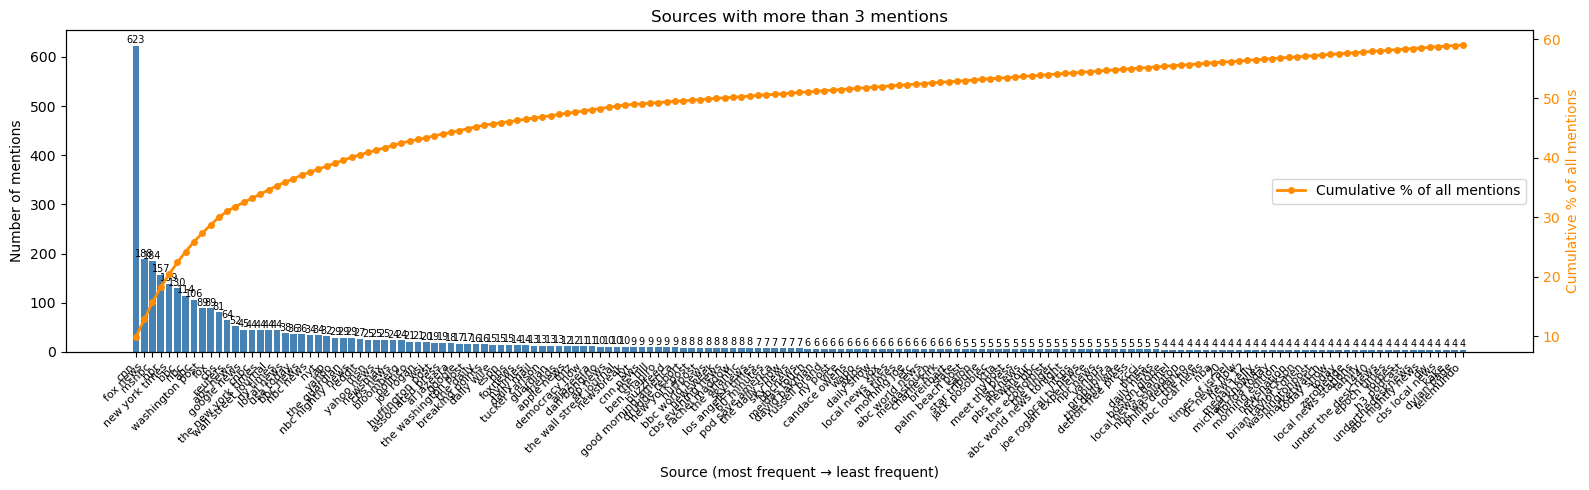

Total mentions in dataset: 6355

  Top  1 sources cover 623 of 6355 mentions (9.8%)
  Top  5 sources cover 1291 of 6355 mentions (20.3%)
  Top 10 sources cover 1819 of 6355 mentions (28.6%)
  Top 20 sources cover 2311 of 6355 mentions (36.4%)
  Top 40 sources cover 2819 of 6355 mentions (44.4%)
  Top 80 sources cover 3240 of 6355 mentions (51.0%)
  Top 161 sources cover 3629 of 6355 mentions (57.1%)


In [ ]:
total_mentions = freq['count'].sum()
top_sources = freq.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with more than 3 mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 3b: How many strings contain 'like' or 'from'?

These are sentences where a source name is embedded after like and from.
We want to know how common it is.

In [8]:
long_strings = all_cleaned

like_mask = long_strings.str.contains(r'\blike\b', regex=True, na=False)
from_mask = long_strings.str.contains(r'\bfrom\b', regex=True, na=False)

print(f"Total cleaned strings:         {len(all_cleaned)}")
print(f"Long strings (>=25 chars):     {len(all_cleaned)} ({len(all_cleaned)/len(all_cleaned)*100:.1f}%)")
print(f"  containing 'like':           {like_mask.sum()}")
print(f"  containing 'from':           {from_mask.sum()}")
print()
print("Sample 'like' sentences:")
for s in long_strings[like_mask].head(8).tolist():
    print(f"  {repr(s)}")
print()
print("Sample 'from' sentences:")
for s in long_strings[from_mask].head(8).tolist():
    print(f"  {repr(s)}")

Total cleaned strings:         6355
Long strings (>=25 chars):     6355 (100.0%)
  containing 'like':           15
  containing 'from':           47

Sample 'like' sentences:
  'show pages that i follow like the black keys'
  'content creators that i follow like arnold'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'entertainment news like movieweb'
  'entertainment news from various content creators like alanah pearce'
  'news sources on specific issues like woods hole oceanagraphic institute'
  'local news youtube channels like wral'
  'maybe some random other videos like hasan that i only watch occasionally'

Sample 'from' sentences:
  'film news from bands'
  'entertainment news from actors'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'political news from the majority report'
  'entertainment news from various content creators like alanah pearce'
  'just w

# Step 4: Extract frequent words from long sentences

Instead of scanning for known names, we take all strings that appear >3 times and
look for them as substrings inside the long sentences.
The idea: if 'cnn' is frequent and a sentence contains 'cnn', we extract 'cnn'. 

In [9]:
freq_names = set(freq[freq['count'] > 3]['source'].tolist()) 
candidate_names = sorted(
    list(freq_names),
    key=len, reverse=True   # longest first — 'new york times' before 'times'
)
print(f"Candidate source names (frequent): {len(candidate_names)}")
print(f"Top 30: {candidate_names[:30]}")

Candidate source names (frequent): 161
Top 30: ['the wall street journal', 'abc world news tonight', 'joe rogan experience', 'good morning america', 'wall street journal', 'under the desk news', 'local news stations', 'the washington post', 'local news channel', 'detroit free press', 'the new york times', 'brian taylor cohen', 'los angeles times', 'associated press', 'local news sites', 'abc nightly news', 'pod save america', 'nbc nightly news', 'underthedesknews', 'cbs evening news', 'michael knowles', 'morning edition', 'breaking points', 'palm beach post', 'times of israel', 'huffington post', 'washington post', 'philip defranco', 'abc world news', 'washingtonpost']


In [10]:
def extract_frequent(s, candidates):
    """Return all frequent names found as whole words inside s.
    If multiple candidates match (e.g. 'bbc or cnn'), each match becomes its own
    row via the explode() call below.  If nothing matches, return s unchanged.
    """
    found = [name for name in candidates
             if re.search(r'\b' + re.escape(name) + r'\b', s)]
    return found if found else [s]

# Explode multi-match results so 'bbc or cnn' → two separate rows
step4_series = all_cleaned.apply(lambda s: extract_frequent(s, candidate_names))
all_extracted_step4 = step4_series.explode().reset_index(drop=True)

# How many strings got resolved (changed)?
original_repeated = all_cleaned.loc[all_cleaned.index.repeat(
    step4_series.apply(len)
)].reset_index(drop=True)
resolved_4 = (all_extracted_step4 != original_repeated).sum()
unresolved_4 = len(all_extracted_step4) - resolved_4

print(f"  Rows after explode:             {len(all_extracted_step4)} (was {len(all_cleaned)})")
print(f"  Resolved by frequent-name scan: {resolved_4} ({resolved_4/len(all_extracted_step4)*100:.1f}%)")
print(f"  Still unresolved:               {unresolved_4}")

# Show some resolved examples
examples_4 = pd.DataFrame({
    'Before': original_repeated.values,
    'After':  all_extracted_step4.values
})
resolved_examples = examples_4[examples_4['Before'] != examples_4['After']]
print(f"\nSample resolved:")
with pd.option_context('display.max_colwidth', 90):
    print(resolved_examples.head(15).to_string())

  Rows after explode:             7433 (was 6355)
  Resolved by frequent-name scan: 1578 (21.2%)
  Still unresolved:               5855

Sample resolved:
                                                                 Before    After
15  entertainment news from various content creators like alanah pearce  various
20                                                       new york times    times
22                                                    los angeles times    times
23                                                                abc 7      abc
28                                                          google news   google
30                                                           yahoo news    yahoo
34                                                       new york times    times
38                                                       new york times    times
49                                                             fox news      fox
70                                  

In [11]:
# New frequency table after step 4
freq_4 = all_extracted_step4.value_counts().reset_index()
freq_4.columns = ['source', 'count']
freq_4['cumulative_pct'] = (freq_4['count'].cumsum() / freq_4['count'].sum() * 100).round(1)

top_4 = freq_4[freq_4['count'] > 3].copy()
unique_before = all_cleaned.nunique()
unique_after_4 = all_extracted_step4.nunique()

print(f"Unique strings before step 4: {unique_before}")
print(f"Unique strings after  step 4: {unique_after_4}")
print(f"Reduced by: {unique_before - unique_after_4} ({(unique_before-unique_after_4)/unique_before*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_4.to_string())

Unique strings before step 4: 2506
Unique strings after  step 4: 2079
Reduced by: 427 (17.0%)

                      source  count  cumulative_pct
0                        cnn    654             8.8
1                        fox    321            13.1
2                      times    302            17.2
3                        nbc    208            20.0
4                        abc    207            22.8
5                      msnbc    200            25.5
6                        bbc    200            28.1
7                   fox news    196            30.8
8             new york times    193            33.4
9                        npr    192            36.0
10                       cbs    138            37.8
11           washington post    110            39.3
12                local news    105            40.7
13                    google     82            41.8
14                     today     67            42.7
15                   reuters     65            43.6
16                   

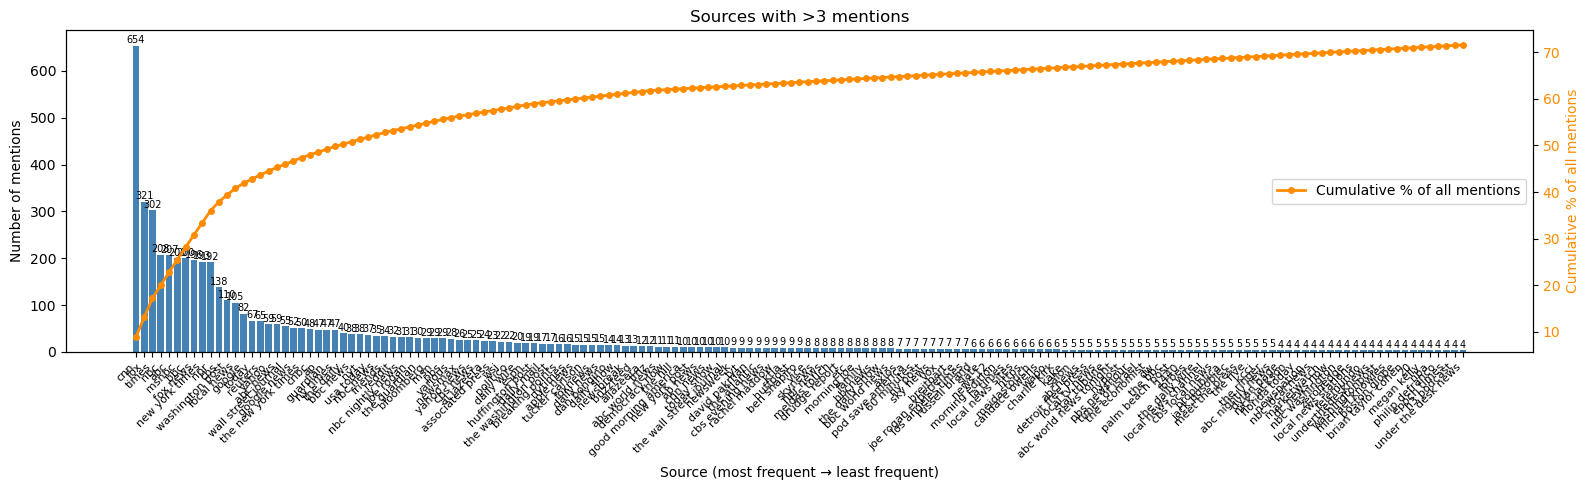

Total mentions in dataset: 7433

  Top  1 sources cover 654 of 7433 mentions (8.8%)
  Top  5 sources cover 1692 of 7433 mentions (22.8%)
  Top 10 sources cover 2673 of 7433 mentions (36.0%)
  Top 20 sources cover 3465 of 7433 mentions (46.6%)
  Top 40 sources cover 4191 of 7433 mentions (56.4%)
  Top 80 sources cover 4759 of 7433 mentions (64.0%)
  Top 161 sources cover 5207 of 7433 mentions (70.1%)


In [12]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = freq_4['count'].sum()
top_sources = freq_4.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with >3 mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step4.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 5: Social-media column audit

What did people actually write in the Facebook / Instagram / TikTok / Twitter / YouTube columns?

We expect SM platform names — but some people wrote mainstream media sources there (e.g. 'CNN' in the YouTube column).
This step is **diagnostic only**: it shows what is in the SM columns before unification.
All actual cleaning and alias resolution happens in Step 6, which runs on ALL sources.


In [13]:
sm_col_entries = exploded[exploded['col_type'] == 'SM_col']['cleaned'].copy()
sm_col_entries_extracted = (
    sm_col_entries
    .apply(lambda s: extract_frequent(s, candidate_names))
    .explode()
    .reset_index(drop=True)
)

sm_freq = sm_col_entries_extracted.value_counts().reset_index()
sm_freq.columns = ['source', 'count']

# Sources in SM columns that also appear in the overall frequent list (candidate_names).
# We call these "known sources in SM columns" — NOT necessarily mainstream media,
# since popular SM-native creators (e.g. Hasanabi) are also frequent.
# Actual MM vs SM classification happens in Step 8 using the category map.
known_in_sm = sm_freq[sm_freq['source'].isin(candidate_names)].copy()
sm_only = sm_freq[~sm_freq['source'].isin(candidate_names)].copy()

# Note on counts: SM column entries after splitting (2838) can exceed original SM cells
# because one cell like "CNN, BBC" becomes 2 entries after Step 1 splitting.
print(f"All SM column entries (after splitting): {len(sm_col_entries_extracted)}")
print(f"  Known sources (in frequent list):  {len(known_in_sm)}")
print(f"  SM-only strings (not in freq list): {len(sm_only)}")

print("\n=== Known sources found in SM columns ===")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    display(known_in_sm.reset_index(drop=True))

print("\n=== SM-only strings (not in frequent list) ===")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    display(sm_only.reset_index(drop=True))


All SM column entries: 2838
MM-in-SM sources: 144
SM-specific sources: 1075

=== MM-in-SM (mainstream media found in social-media columns) ===


,source,count
0,cnn,241
1,bbc,102
2,fox,99
3,times,73
4,msnbc,68
5,abc,58
6,nbc,58
7,fox news,53
8,new york times,43
9,npr,37



=== SM-specific (strings not in candidate_names) ===


,source,count
0,penguinz0,3
1,matt wallace,3
2,tim pool,3
3,content creators,3
4,trending,3
5,facebook,3
6,rap,3
7,hasanabi,3
8,last week tonight,3
9,elon musk,3


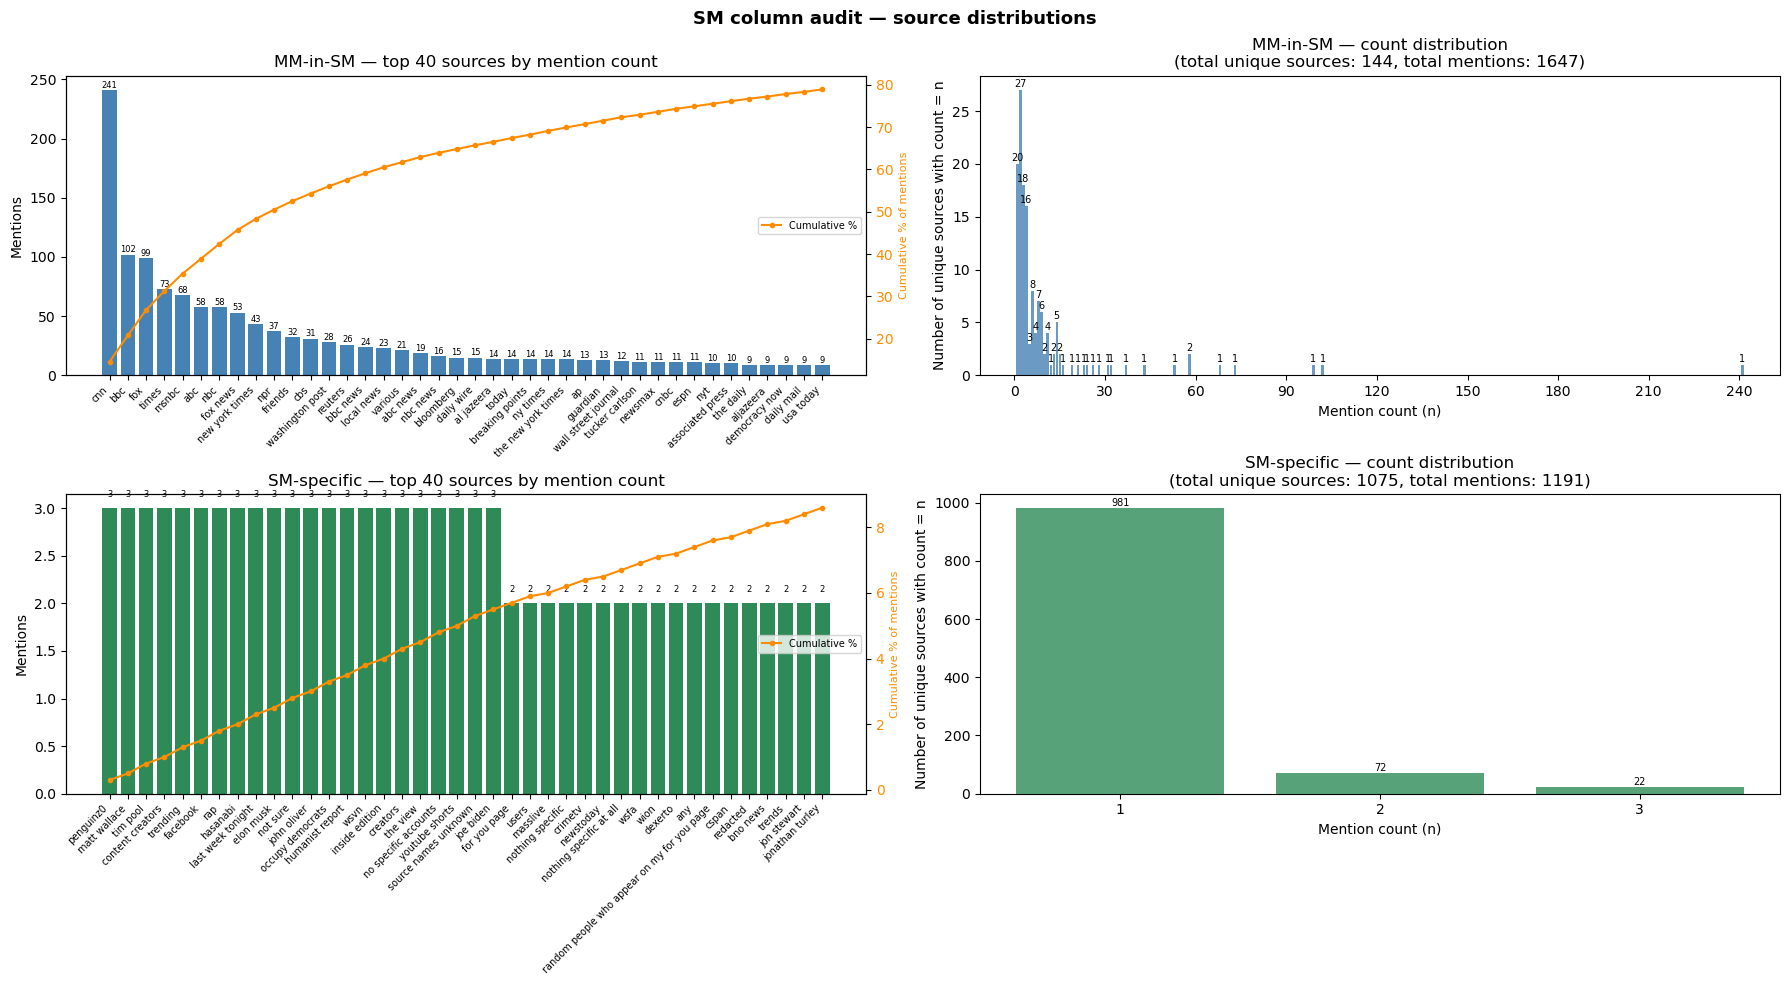

MM-in-SM:
  Unique sources: 144
  Total mentions: 1647
  Appear once:    20
  Appear 2-3x:    45
  Appear 4+:      79

SM-specific:
  Unique sources: 1075
  Total mentions: 1191
  Appear once:    981
  Appear 2-3x:    94
  Appear 4+:      0



In [14]:
# Distribution charts for Known-in-SM and SM-only sources
# Left panel:  bar chart of top sources by mention count
# Right panel: mention-count distribution (how many sources have count=1, 2, 3, ...)
# Style matches the Step 3a chart

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('SM column audit — source distributions', fontsize=13, fontweight='bold')

for row_idx, (df, label, colour) in enumerate([
    (known_in_sm,   'Known-in-SM',    'steelblue'),
    (sm_only, 'SM-only', 'seagreen'),
]):
    # ── left panel: top-N bar chart (up to 40 sources) ──────────────────────
    top_n = df.head(40).copy()
    ax_bar = axes[row_idx][0]
    bars = ax_bar.bar(range(len(top_n)), top_n['count'], color=colour)
    ax_bar.set_xticks(range(len(top_n)))
    ax_bar.set_xticklabels(top_n['source'], rotation=45, ha='right', fontsize=7)
    ax_bar.set_ylabel('Mentions')
    ax_bar.set_title(f'{label} — top {len(top_n)} sources by mention count')
    for bar, val in zip(bars, top_n['count']):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=6)

    # cumulative % line on twin axis
    total = df['count'].sum()
    top_n['cumulative_pct'] = (top_n['count'].cumsum() / total * 100).round(1)
    ax2 = ax_bar.twinx()
    ax2.plot(range(len(top_n)), top_n['cumulative_pct'],
             color='darkorange', marker='o', markersize=3, linewidth=1.5,
             label='Cumulative %')
    ax2.set_ylabel('Cumulative % of mentions', color='darkorange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.legend(loc='center right', fontsize=7)

    # ── right panel: distribution of counts (long-tail view) ────────────────
    ax_dist = axes[row_idx][1]
    count_dist = df['count'].value_counts().sort_index()
    ax_dist.bar(count_dist.index, count_dist.values, color=colour, alpha=0.8)
    ax_dist.set_xlabel('Mention count (n)')
    ax_dist.set_ylabel('Number of unique sources with count = n')
    ax_dist.set_title(f'{label} — count distribution\n'
                      f'(total unique sources: {len(df)}, total mentions: {total})')
    ax_dist.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for x, y in zip(count_dist.index, count_dist.values):
        ax_dist.text(x, y + 0.1, str(y), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('sm_audit_distributions.png', dpi=150)
plt.show()

# Summary stats
for df, label in [(known_in_sm, 'Known-in-SM'), (sm_only, 'SM-only')]:
    total = df['count'].sum()
    print(f"{label}:")
    print(f"  Unique sources: {len(df)}")
    print(f"  Total mentions: {total}")
    print(f"  Appear once:    {(df['count'] == 1).sum()}")
    print(f"  Appear 2-3x:    {df['count'].between(2, 3).sum()}")
    print(f"  Appear 4+:      {(df['count'] > 3).sum()}")
    print()


# Step 6: Unification — applied to ALL sources

All hardcoded dictionaries and normalisation rules live here and are applied to every source in the dataset,
regardless of whether it came from an MM or SM survey column.

The `unify()` function runs four operations in sequence:
1. **Platform-prefix strip** — removes 'youtube - ', 'tiktok: ', etc. from the start of a string
2. **Noise filter** — replaces generic/junk strings with `'NOISE'` (excluded from final table)
3. **Spacing normalisation** — collapses double spaces, strips leading @/#, hyphen → space
4. **Alias map** — maps all known variant spellings to one standard source name (MM and SM entries together)


In [15]:
# Fires when a known platform word is at the very start followed by a separator
# e.g. 'youtube - penguinz0' → 'penguinz0', 'tiktok: beau of the fifth column' → 'beau of the fifth column'
PLATFORM_PREFIXES = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'

# Strings that are clearly not source names — applied to ALL columns
NOISE_EXACT = {
    'n/a', 'na', 'n', 'a', 'no', 'none', 'nothing', 'not sure',
    'various', 'many', 'other', 'others', 'posts', 'ads', 'them',
    'users', 'content', 'creators', 'trending', 'explore page',
    'news feed', 'for you page', 'my feed', 'impact',
    'no specific sources', 'no specific accounts', 'not specific',
    'nothing specific', 'nothing specific at all', 'source names unknown',
    'independent journalists', 'random people', 'forum links',
    'advertisements', 'just following links from elsewhere',
    'only what shows up in my feed', 'i just read my feed',
    'random people who appear on my for you page',
    'rap', 'democrats', 'newstoday', 'america news',
    # bare generic words that appear as extraction artefacts
    'times', 'news', 'post', 'daily', 'report', 'review', 'online',
    'media', 'channel', 'network', 'radio', 'tv', 'web',
}

NOISE_PATTERNS = [
    r'^\d+$',                           # pure number
    r'^[a-z]$',                          # single letter
    r'\bjust\s+follow',
    r'\bonly\s+what\s+shows',
    r'\brandom\s+people\b',
    r'\bfor\s+you\s+page\b',
    r'\bmy\s+feed\b',
    r'\bnews\s+feed\b',
    r'\bno\s+specific\b',
    r'\bnothing\s+specific\b',
    r'\bsource\s+names\s+unknown\b',
]

# Order matters: more specific patterns come first.
# \b = word boundary — \bcnn\b matches 'cnn' but not 'xcnn'
ALIAS_MAP = [
        (r'\bfox\s*1[0-9]\b',                   'Fox 13'),
    (r'\bgoogle\s+discover\b',               'Google Discover'),

        # 'times' alone is NOT matched — too ambiguous (Financial Times, LA Times, etc.)
    (r'\bthe\s+new\s+york\s+times?\b',     'New York Times'),
    (r'\bnew\s+york\s+times?\b',            'New York Times'),
    (r'\bnytimes?\b',                         'New York Times'),
    (r'\bny\s+times?\b',                     'New York Times'),
    (r'\bnyt\b',                              'New York Times'),

        (r'\bcnn\s*news?\b',                     'CNN'),
    (r'\bcnn\b',                              'CNN'),

        (r'\bsky\s*news\b',                      'Sky News'),
    (r'\bskynews\b',                          'Sky News'),

        (r'\bfox\s+news\b',                      'Fox News'),
    (r'\bfoxnews\b',                          'Fox News'),
    (r'\blivenow\s+from\s+fox\b',           'Fox News'),
    (r'\bfox\b(?!\s*\d)',                   'Fox News'),

        (r'\bbbcnews\b',                          'BBC News'),
    (r'\bbbc\s+world\s+news\b',             'BBC News'),
    (r'\bbbc\s+world\b',                     'BBC News'),
    (r'\bbbc(?:\s+news)?\b',                 'BBC News'),

        (r'\bthe\s+washington\s+post\b',        'Washington Post'),
    (r'\bwashington\s+post\b',               'Washington Post'),
    (r'\bwapo\b',                             'Washington Post'),
    (r'\bwashpost\b',                         'Washington Post'),
    (r'\bwashingtonpost\b',                   'Washington Post'),
    (r'\btwp\b',                              'Washington Post'),

        (r'\bmsnbc\b',                            'MSNBC'),

        (r'\bnbc\s+nightly\s+news\b',           'NBC News'),
    (r'\bnbc\s+washington\b',                'NBC News'),
    (r'\bnbc(?:\s+news)?\b',                 'NBC News'),

        (r'\babc\s+world\s+news\b',             'ABC News'),
    (r'\bgood\s+morning\s+america\b',       'ABC News'),
    (r'\babc\s*\d+\s*(?:news)?\b',         'ABC News'),
    (r'\babc(?:\s+news)?\b',                 'ABC News'),

        (r'\bcbs\s+evening\s+news\b',           'CBS News'),
    (r'\b60\s+minutes\b',                    'CBS News'),
    (r'\bcbs(?:\s+news)?\b',                 'CBS News'),

        (r'\bnpr\b',                              'NPR'),
    (r'\bnational\s+public\s+radio\b',      'NPR'),

        (r'\bpbs(?:\s+news(?:hour)?)?\b',        'PBS NewsHour'),

        (r'\bassociated\s+press\b',              'Associated Press'),
    (r'\bapnews\b',                           'Associated Press'),
    (r'\bap\s+news\b',                       'Associated Press'),
    (r'\bap\b',                               'Associated Press'),

        (r'\breuters\b',                          'Reuters'),

        (r'\bthe\s+wall\s+street\s+journal\b', 'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b',        'Wall Street Journal'),
    (r'\bwallstreet\s+journal\b',            'Wall Street Journal'),
    (r'\bwsj\b',                              'Wall Street Journal'),

        (r'\bal\s+jazeera\b',                    'Al Jazeera'),
    (r'\baljazeera\b',                        'Al Jazeera'),

        (r'\byahoo(?:\s+news)?\b',               'Yahoo News'),
    (r'\bgoogle(?:\s+news)?\b',              'Google News'),
    (r'\bapple\s+news\b',                    'Apple News'),
    (r'\bmsn\b',                              'MSN News'),
    (r'\bflipboard\b',                        'Flipboard'),
    (r'\bground\.news\b',                    'Ground News'),
    (r'\bground\s+news\b',                   'Ground News'),
    (r'\bnews\s*break\b',                    'NewsBreak'),
    (r'\b1440\b',                             '1440 Daily Digest'),

        (r'\batlanta\s+journal[\s\-]+constitution\b', 'Atlanta Journal-Constitution'),
    (r'\batlanta\s+journal\b',               'Atlanta Journal-Constitution'),
    (r'\bajc\b',                              'Atlanta Journal-Constitution'),

        (r'\bfacebook\s+news\b',                 'Facebook'),   # FB news tab = FB platform
    (r'\bfacebook\b',                         'Facebook'),
    (r'\bfb\b',                               'Facebook'),
    (r'\binstagram\b',                        'Instagram'),
    (r'\big\b(?!n)',                          'Instagram'),
    (r'\btiktok\b',                           'TikTok'),
    (r'\btwitter\b',                          'Twitter/X'),
    (r'\bx\.com\b',                          'Twitter/X'),
    (r'\byoutube\s+shorts\b',                'YouTube'),
    (r'\byoutube\b',                          'YouTube'),
    (r'\byt\b',                               'YouTube'),
    (r'\breddit\b',                           'Reddit'),
    (r'\bsnapchat\b',                         'Snapchat'),
    (r'\bdiscord\b',                          'Discord'),
    (r'\bpinterest\b',                        'Pinterest'),
    (r'\blinkedin\b',                         'LinkedIn'),
    (r'\bthreads\b',                          'Threads'),
    (r'\bbluesky\b',                          'Bluesky'),
    (r'\bmastodon\b',                         'Mastodon'),
    (r'\btwitch\b',                           'Twitch'),

        (r'\busa\s+today\b',                     'USA Today'),
    (r'\bla\s+times\b',                      'Los Angeles Times'),
    (r'\blos\s+angeles\s+times\b',          'Los Angeles Times'),
    (r'\blatimes\b',                          'Los Angeles Times'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),
    (r'\bnewsweek\b',                         'Newsweek'),
    (r'\btime\s+magazine\b',                 'TIME Magazine'),   # 'time' alone NOT matched
    (r'\bpolitico\b',                         'Politico'),
    (r'\bbloomberg\b',                        'Bloomberg'),
    (r'\bcnbc\b',                             'CNBC'),
    (r'\bforbes\b',                           'Forbes'),
    (r'\bthe\s+economist\b',                 'The Economist'),
    (r'\beconomist\b',                        'The Economist'),
    (r'\bfinancial\s+times\b',               'Financial Times'),
    (r'\bvox\b',                              'Vox'),
    (r'\bthe\s+atlantic\b',                  'The Atlantic'),
    (r'\batlantic\b',                         'The Atlantic'),
    (r'\bnew\s+yorker\b',                    'The New Yorker'),
    (r'\bthe\s+guardian\b',                  'The Guardian'),
    (r'\bguardian\b',                         'The Guardian'),
    (r'\btheguardian\b',                      'The Guardian'),
    (r'\baxios\b',                            'Axios'),
    (r'\bthe\s+hill\b',                      'The Hill'),
    (r'\bhuffpost\b',                         'HuffPost'),
    (r'\bhuffington\s+post\b',               'HuffPost'),
    (r'\bbuzzfeed\b',                         'BuzzFeed'),
    (r'\bespn\b',                             'ESPN'),
    (r'\bbreitbart\b',                        'Breitbart'),
    (r'\bthe\s+daily\s+wire\b',             'Daily Wire'),
    (r'\bdaily\s+wire\b',                    'Daily Wire'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bdaily\s+mail\b',                    'Daily Mail'),
    (r'\bnypost\b',                           'New York Post'),
    (r'\bnew\s+york\s+post\b',              'New York Post'),
    (r'\bny\s+post\b',                       'New York Post'),
    (r'\bnewsmax\b',                          'Newsmax'),
    (r'\bnewsnation\b',                       'NewsNation'),
    (r'\bdw\b',                               'DW (Deutsche Welle)'),
    (r'\bdeutsche\s+welle\b',                'DW (Deutsche Welle)'),
    (r'\bpropublica\b',                       'ProPublica'),
    (r'\btmz\b',                              'TMZ'),
    (r'\bslate\b',                            'Slate'),
    (r'\bvice\b',                             'Vice'),
    (r'\bsalon\b',                            'Salon'),
    (r'\bzerohedge\b',                        'ZeroHedge'),
    (r'\bmarketwatch\b',                      'MarketWatch'),
    (r'\btelemundo\b',                        'Telemundo'),
    (r'\bunivision\b',                        'Univision'),
    (r'\bcbc\b',                              'CBC'),
    (r'\bc-?span\b',                          'C-SPAN'),
    (r'\bdrudge\s*report\b',                 'Drudge Report'),
    (r'\breal\s+clear\s+politics\b',        'RealClearPolitics'),
    (r'\bpolitifact\b',                       'PolitiFact'),
    (r'\bsnopes\b',                           'Snopes'),
    (r'\bgreenbrier\s+news\b',               'Greenbrier News'),
    (r'\bwion\b',                             'WION'),
    (r'\bbn[o0]\s+news\b',                   'BNO News'),
    (r'\bbarstool(?:\s+sports)?\b',          'Barstool Sports'),
    (r'\bhollywood\s+unlocked\b',            'Hollywood Unlocked'),
    (r'\bthe\s+shade\s+room\b',             'The Shade Room'),
    (r'\bshade\s+room\b',                    'The Shade Room'),
    (r'\binside\s+edition\b',                'Inside Edition'),
    (r'\bmeidas\s*touch\b',                  'MeidasTouch'),
    (r'\boccupy\s+democrats\b',              'Occupy Democrats'),
    (r'\bthe\s+athletic\b',                  'The Athletic'),
    (r'\bathletic\b',                         'The Athletic'),
    (r'\btmz\b',                              'TMZ'),

        (r'\bthe\s+daily\s+show\b',             'The Daily Show'),
    (r'\bdaily\s+show\b',                    'The Daily Show'),
    (r'\bthe\s+view\b',                      'The View'),
    (r'\bjohn\s+oliver\b',                   'John Oliver'),
    (r'\blast\s+week\s+tonight\b',          'John Oliver'),
    (r'\bjon\s+stewart\b',                   'Jon Stewart'),
    (r'\bjohn\s+stewart\b',                  'Jon Stewart'),
    (r'\bseth\s+mey[oe]rs?\b',               'Seth Meyers'),
    (r'\bsome\s+more\s+news\b',             'Some More News'),
    (r'\bunder\s*the\s*desk\s*news\b',     'Under the Desk News'),
    (r'\bunderthedesknews\b',                 'Under the Desk News'),

        (r'\bbreaking\s+points\b',               'Breaking Points'),
    (r'\bdemocracy\s+now\b',                 'Democracy Now'),
    (r'\bpod\s+save\s+america\b',           'Pod Save America'),

        (r'\bthe\s+young\s+turks\b',            'TYT'),
    (r'\byoung\s+turks\b',                   'TYT'),
    (r'\btyt\b',                              'TYT'),
    (r'\bhasanabi\b',                         'Hasanabi'),
    (r'\bhasan\s+piker\b',                   'Hasanabi'),
    (r'\bpenguinz0\b',                        'Penguinz0'),
    (r'\bmoist\s*cr1tikal\b',                'Penguinz0'),
    (r'\btim\s+pool\b',                      'Tim Pool'),
    (r'\btimcast\b',                          'Tim Pool'),
    (r'\bmark\s+dice\b',                     'Mark Dice'),
    (r'\bandy\s+ngo\b',                      'Andy Ngo'),
    (r'\bmatt\s+walsh\b',                    'Matt Walsh'),
    (r'\bmatt\s+wallace\b',                  'Matt Wallace'),
    (r'\belon\s+musk\b',                     'Elon Musk'),
    (r'\belonmusk\b',                         'Elon Musk'),
    (r'\bjordan\s+peterson\b',               'Jordan Peterson'),
    (r'\bgeorge\s+conway\b',                 'George Conway'),
    (r'\bglenn?\s+greenwald\b',              'Glenn Greenwald'),
    (r'\bjonathan\s+turley\b',               'Jonathan Turley'),
    (r'\bbeau\s+of\s+the\s+fifth\s+column\b', 'Beau of the Fifth Column'),
    (r'\bmajority\s+report\b',               'Majority Report'),
    (r'\bsecular\s+talk\b',                  'Secular Talk'),
    (r'\bbrian\s+tyler\s+cohen\b',          'Brian Tyler Cohen'),
    (r'\bthe\s+rational\s+national\b',      'The Rational National'),
    (r'\brational\s+national\b',             'The Rational National'),
    (r'\bthe\s+humanist\s+report\b',        'Humanist Report'),
    (r'\bhumanist\s+report\b',               'Humanist Report'),
    (r'\bzero\s+hedge\b',                    'ZeroHedge'),
    (r'\bred[a]cted\b',                       'Redacted'),

        (r'\bnew\s*york\s*tomes?\b',            'New York Times'),   # typo 'Tomes'
    (r'\bnewyorktimes?\b',                    'New York Times'),
    (r'\bwallstreetjournal\b',                'Wall Street Journal'),
    (r'\busatoday\b',                         'USA Today'),
    (r'\bnbcnews\b',                          'NBC News'),
    (r'\bcbsnews\b',                          'CBS News'),
    (r'\babcnews\b',                          'ABC News'),
    (r'\bhuff\s+post\b',                     'HuffPost'),
    (r'\bdailymail\b',                        'Daily Mail'),
    (r'\bdailymirror\b',                      'Daily Mirror'),
    (r'\bpropublica\b',                       'ProPublica'),
    (r'\bpro\s+publica\b',                   'ProPublica'),
    (r'\bnytimes?\b',                         'New York Times'),
    (r'\bwapo\b',                             'Washington Post'),
    (r'\bwashpost\b',                         'Washington Post'),
    (r'\bpod\s+saves?\s+america\b',         'Pod Save America'),  # typo 'saves'
    (r'\bnews\s*nation\b',                   'NewsNation'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
    (r'\bblazetv\b',                          'BlazeTV'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bblaze\s+tv\b',                      'BlazeTV'),
    (r'\bepoch\s+times\b',                   'Epoch Times'),
    (r'\bnational\s+review\b',               'National Review'),
    (r'\bthe\s+intercept\b',                 'The Intercept'),
    (r'\bintercept\b',                        'The Intercept'),
    (r'\bjacobins?\b',                        'Jacobin'),
    (r'\bthe\s+bulwark\b',                   'The Bulwark'),
    (r'\bbulwark\b',                          'The Bulwark'),
    (r'\bbusiness\s+insider\b',              'Business Insider'),
    (r'\bjJerusalem\s+post\b',               'Jerusalem Post'),
    (r'\bjPost\b',                            'Jerusalem Post'),
    (r'\btimes\s+of\s+israel\b',            'Times Of Israel'),
    (r'\bchicago\s+tribune\b',               'Chicago Tribune'),
    (r'\bhouston\s+chronicle\b',             'Houston Chronicle'),
    (r'\bdetroit\s+free\s+press\b',         'Detroit Free Press'),
    (r'\bstar\s+tribune\b',                  'Star Tribune'),
    (r'\bpalm\s+beach\s+post\b',            'Palm Beach Post'),
    (r'\bflorida\s+today\b',                 'Florida Today'),
    (r'\bnewsday\b',                          'Newsday'),
    (r'\bpenn\s*live\b',                     'PennLive'),
    (r'\bmasslive\b',                         'MassLive'),
    (r'\bthe\s+telegraph\b',                 'The Telegraph'),
    (r'\btelegraph\b',                        'The Telegraph'),
    (r'\bmiddle\s+east\s+eye\b',            'Middle East Eye'),
    (r'\bvoa\b',                              'Voice of America'),
    (r'\bvoice\s+of\s+america\b',           'Voice of America'),
    (r'\bnpr\s+news\b',                      'NPR'),
    (r'\bup\s+first\b',                      'NPR'),           # NPR daily podcast
    (r'\bmorning\s+edition\b',               'NPR'),           # NPR morning programme
    (r'\ball\s+things\s+considered\b',      'NPR'),           # NPR afternoon programme
    (r'\bmarketplace\b',                      'NPR'),           # NPR business programme
    (r'\bthis\s+american\s+life\b',         'This American Life'),
    (r'\bsirius\s*xm\b',                     'SiriusXM'),
    (r'\bspotify\b',                          'Spotify'),
    (r'\bhaystack\b',                         'Haystack News'),
    (r'\bsmartNews\b',                        'SmartNews'),
    (r'\bsmart\s*news\s+app\b',             'SmartNews'),
    (r'\bbing\b',                             'Bing News'),
    (r'\bdrudge\b(?!\s*report)',             'Drudge Report'),
        (r'\bjoe\s+rogan\s+experience\b',       'Joe Rogan'),
    (r'\bjoe\s+rogan\b',                     'Joe Rogan'),
    (r'\btimcastirl\b',                       'Tim Pool'),
    (r'\btucker\s+carlson\b',                'Tucker Carlson'),
    (r'\btucker\b(?!\s+carlson)',            'Tucker Carlson'),
    (r'\bben\s+shapiro\b',                   'Ben Shapiro'),
    (r'\brachel\s+maddow\b',                 'Rachel Maddow'),
    (r'\bmegyn?\s+kell?ey?\b',              'Megyn Kelly'),   # Megan Kelly / Megyn Kelly
    (r'\bmegan\s+kell?ey?\b',               'Megyn Kelly'),
    (r'\banderson\s+cooper\b',               'Anderson Cooper'),
    (r'\bdan\s+bongino\b',                   'Dan Bongino'),
    (r'\bdavid\s+pakman\b',                  'David Pakman'),
    (r'\bdpakman\b',                          'David Pakman'),
    (r'\bphilip\s+de\s*franco\b',           'Philip DeFranco'),
    (r'\bphilip\s+di\s*franco\b',           'Philip DeFranco'),
    (r'\bphil\s+de\s*franco\b',             'Philip DeFranco'),
    (r'\bphilip\s+defranco\b',               'Philip DeFranco'),
    (r'\bphilp\s+defranco\b',                'Philip DeFranco'),
    (r'\bphilipp?\s*defranco\b',             'Philip DeFranco'),
    (r'\bpdefranco\b',                        'Philip DeFranco'),
    (r'\bphil\s+defranco\b',                 'Philip DeFranco'),
    (r'\bbrian\s+tay(?:lor|ler)\s+cohen\b', 'Brian Tyler Cohen'),  # typo 'taylor'
    (r'\bjack\s+posobiec\b',                 'Jack Posobiec'),
    (r'\bcharlie\s+kirk\b',                  'Charlie Kirk'),
    (r'\bmichael\s+knowles\b',               'Michael Knowles'),
    (r'\bmark\s+levin\b',                    'Mark Levin'),
    (r'\bglenn\s+beck\b',                    'Glenn Beck'),
    (r'\brussell\s+brand\b',                 'Russell Brand'),
    (r'\brusselbrand\b',                      'Russell Brand'),
    (r'\bcandace\s+owens\b',                 'Candace Owens'),
    (r'\bcandice\s+owens\b',                 'Candace Owens'),
    (r'\bchris\s+hayes\b',                   'Chris Hayes'),
    (r'\bari\s+melber\b',                    'Ari Melber'),
    (r'\blawrence\s+o.?donnell\b',           "Lawrence O'Donnell"),
    (r'\bjimmy\s+dore\b',                    'Jimmy Dore'),
    (r'\bsam\s+seder\b',                     'Sam Seder'),
    (r'\bdylan\s+page\b',                    'Dylan Page'),
    (r'\bdylan\.page\b',                     'Dylan Page'),
    (r'\bmorning\s+joe\b',                   'Morning Joe'),
    (r'\bh3\s+podcast\b',                    'H3 Podcast'),
    (r'\bpbd\s+podcast\b',                   'PBD Podcast'),
    (r'\bstephen\s+colbert\b',               'Stephen Colbert'),
    (r'\bcolbert\b',                          'Stephen Colbert'),
    (r'\bnick\s+jackson\b',                  'Nick Jackson'),
    (r'\bthe\s+five\b',                      'The Five'),        # Fox News programme
    (r'\bmeet\s+the\s+press\b',             'Meet The Press'),  # NBC programme
    (r'\bthe\s+ringer\b',                    'The Ringer'),
        (r'\bwbal\b',                             'WBAL'),
    (r'\bwbbm\b',                             'WBBM'),
    (r'\bwfla\b',                             'WFLA'),
    (r'\bwfmz\b',                             'WFMZ'),
    (r'\bwgal\b',                             'WGAL'),
    (r'\bwsvn\b',                             'WSVN'),
    (r'\bwsfa\b',                             'WSFA'),
    (r'\bwsbtv\b',                            'WSB-TV'),
    (r'\bwplg\b',                             'WPLG'),
    (r'\bkcci\b',                             'KCCI'),
    (r'\bkake\b',                             'KAKE'),
    (r'\bkfyr\b',                             'KFYR'),
    (r'\bkcrg\b',                             'KCRG'),
    (r'\bkfvs\b',                             'KFVS'),
    (r'\bktla\b(?!\s*5)',                    'KTLA'),
    (r'\bktla\s*5\b',                        'KTLA'),
    (r'\bksl\b',                              'KSL'),
    (r'\bkare\s*11\b',                       'KARE 11'),
    (r'\bwkbn\b',                             'WKBN'),
    (r'\bwavy\s*10\b',                       'WAVY-TV 10'),
    (r'\bwavy10\b',                           'WAVY-TV 10'),
    (r'\bwxpn\b',                             'WXPN'),
    (r'\bdc\s+news\s+now\b',                'DC News Now'),
    (r'\bnews\s+12\b',                       'News 12'),
    (r'\bnews\s+on\s+6\b',                  'News On 6'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
        (r'\bnightly\s+news\b',                  'NBC News'),   # NBC Nightly News
    (r'\btoday\s+show\b',                    'Today Show'), # NBC Today Show
    (r'\btoday\b(?!\s+show)',                'Today Show'), # bare 'Today'
    (r'\bthe\s+daily\b(?!\s+show|\s+wire)', 'The Daily'), # NYT podcast

        (r'\bnew\s*york\s*tomes?\b',             'New York Times'),
    (r'\bnewyorktimes?\b',                   'New York Times'),
    (r'\bwallstreetjournal\b',               'Wall Street Journal'),
    (r'\bwallstreetjurnal\b',                'Wall Street Journal'),
    (r'\bwall\s+st\s+journal\b',             'Wall Street Journal'),
    (r'\bwall\s+st\.?\s+j\b',               'Wall Street Journal'),
    (r'\busatoday\b',                        'USA Today'),
    (r'\bnbcnews\b',                         'NBC News'),
    (r'\bcbsnews\b',                         'CBS News'),
    (r'\bcbsboston\b',                       'CBS News'),
    (r'\babcnews\b',                         'ABC News'),
    (r'\bhuff\s+post\b',                     'HuffPost'),
    (r'\bhuffnews\b',                        'HuffPost'),
    (r'\bhiffpost\b',                        'HuffPost'),
    (r'\bhiff\s+post\b',                     'HuffPost'),
    (r'\bhuffingto\.\s*post\b',              'HuffPost'),
    (r'\bhuffpo\b',                          'HuffPost'),
    (r'\bdailymail\b',                       'Daily Mail'),
    (r'\bdailymirror\b',                     'Daily Mirror'),
    (r'\bpro\s+publica\b',                   'ProPublica'),
    (r'\bassosciated\s+press\b',             'Associated Press'),
    (r'\brueters\b',                         'Reuters'),
    (r'\bpod\s+saves?\s+america\b',          'Pod Save America'),
    (r'\bnews\s*nation\b',                   'NewsNation'),
    (r'\bnsnbc\b',                           'MSNBC'),
    (r'\bmsmbc\b',                           'MSNBC'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
    (r'\bblazetv\b',                         'BlazeTV'),
    (r'\bblaze\s+tv\b',                      'BlazeTV'),
    (r'\bepoch\s+times\b',                   'Epoch Times'),
    (r'\bnational\s+review\b',               'National Review'),
    (r'\bthe\s+intercept\b',                 'The Intercept'),
    (r'\bintercept\b',                       'The Intercept'),
    (r'\bjacobins?\b',                       'Jacobin'),
    (r'\bjacobian\b',                        'Jacobin'),
    (r'\bthe\s+bulwark\b',                   'The Bulwark'),
    (r'\bbusiness\s+insider\b',              'Business Insider'),
    (r'\binsider\b(?!\s+edition)',           'Business Insider'),
    (r'\bjerusalem\s+post\b',               'Jerusalem Post'),
    (r'\btimes\s+of\s+israel\b',             'Times Of Israel'),
    (r'\bynet\b',                            'Ynet'),
    (r'\bchicago\s+tribune\b',               'Chicago Tribune'),
    (r'\bhouston\s+chronicle\b',             'Houston Chronicle'),
    (r'\bdetroit\s+free\s+press\b',          'Detroit Free Press'),
    (r'\bstar\s+tribune\b',                  'Star Tribune'),
    (r'\bstart\s+tribune\b',                 'Star Tribune'),
    (r'\bstar\s+tribnue\b',                  'Star Tribune'),
    (r'\bpalm\s+beach\s+post\b',             'Palm Beach Post'),
    (r'\bflorida\s+today\b',                 'Florida Today'),
    (r'\bnewsday\b',                         'Newsday'),
    (r'\bpenn\s*live\b',                     'PennLive'),
    (r'\bmasslive\b',                        'MassLive'),
    (r'\bthe\s+telegraph\b',                 'The Telegraph'),
    (r'\btelegraph\b',                       'The Telegraph'),
    (r'\bmiddle\s+east\s+eye\b',             'Middle East Eye'),
    (r'\bmiddle\s+eastern\s+eye\b',          'Middle East Eye'),
    (r'\bvoa\b',                             'Voice of America'),
    (r'\bvoice\s+of\s+america\b',            'Voice of America'),
    (r'\bnpr\s+news\b',                      'NPR'),
    (r'\bup\s+first\b',                      'NPR'),
    (r'\bmorning\s+edition\b',               'NPR'),
    (r'\ball\s+things\s+considered\b',       'NPR'),
    (r'\bfresh\s+air\b',                     'NPR'),
    (r'\bmarketplace\b',                     'NPR'),
    (r'\bthis\s+american\s+life\b',          'This American Life'),
    (r'\bsirius\s*xm\b',                     'SiriusXM'),
    (r'\bxm\s+radio\b',                      'SiriusXM'),
    (r'\biheart\s*radio\b',                  'iHeartRadio'),
    (r'\bspotify\b',                         'Spotify'),
    (r'\bhaystack\b',                        'Haystack News'),
    (r'\bsmart\s*news\b',                    'SmartNews'),
    (r'\bbing\b(?!\s+news)',                 'Bing News'),
    (r'\bdrudge\b(?!\s*report)',             'Drudge Report'),
    (r'\bwashinton\s+post\b',                'Washington Post'),
    (r'\bwash\s+post\b',                     'Washington Post'),
    (r'\bwapost\b',                          'Washington Post'),
    (r'\bbcc\b',                             'BBC News'),      # typo for BBC
    (r'\bcnnbbc\b',                          'CNN'),           # combined → CNN first
    (r'\bcnncnn\b',                          'CNN'),
    (r'\bbloonberg\b',                       'Bloomberg'),
    (r'\bbloomburge\b',                      'Bloomberg'),
    (r'\bbloombergbusiness\b',               'Bloomberg'),
    (r'\bmarket\s+watch\b',                  'MarketWatch'),
    (r'\bbrietbart\b',                       'Breitbart'),
    (r'\bbreibart\b',                        'Breitbart'),
    (r'\bjoerogan\b',                        'Joe Rogan'),
    (r'\brogan\b(?!\s+experience)',          'Joe Rogan'),
    (r'\baj\s+english\b',                    'Al Jazeera'),
    (r'\bajenglish\b',                       'Al Jazeera'),
    (r'\baljazeeraenglish\b',                'Al Jazeera'),
    (r'\baljasera\b',                        'Al Jazeera'),
    (r'\baljazzira\b',                       'Al Jazeera'),
    (r'\bajazeera\b',                        'Al Jazeera'),
    (r'\bal-jazeera\b',                      'Al Jazeera'),
    (r'\baj\s+plus\b',                       'Al Jazeera'),
    (r'\bmedias?\s*touch\b',                 'MeidasTouch'),
    (r'\bmeidas\b(?!\s*touch)',              'MeidasTouch'),
    (r'\bmediastouch\b',                     'MeidasTouch'),
    (r'\bmidas\s+touch\s+network\b',         'MeidasTouch'),
    (r'\bthe\s+weather\s+channel\b',         'The Weather Channel'),
    (r'\bdaily\s+beast\b',                   'Daily Beast'),
    (r'\bpink\s+news\b',                     'PinkNews'),
    (r'\bnew\s+york\s+magazine\b',           'New York Magazine'),
    (r'\bnew\s+york\s+mag\b',               'New York Magazine'),
    (r'\boann?\b',                           'OAN'),
    (r'\boan\s+tv\b',                        'OAN'),
    (r'\boan\s+website\b',                   'OAN'),
    (r'\breal\s+americas?\s+voice\b',        'Real America\'s Voice'),
    (r'\bgateway\s+pundit\b',                'Gateway Pundit'),
    (r'\bthegatewaypundit\b',               'Gateway Pundit'),
    (r'\bthe\s+independent\b',               'The Independent'),
    (r'\bwashington\s+examiner\b',           'Washington Examiner'),
    (r'\bdenver\s+post\b',                   'Denver Post'),
    (r'\bboston\s+herald\b',                 'Boston Herald'),
    (r'\bkansas\s+city\s+star\b',            'Kansas City Star'),
    (r'\bsan\s+francisco\s+chronicle\b',     'San Francisco Chronicle'),
    (r'\barkansas\s+democrat\s*[-–]?\s*gazette\b', 'Arkansas Democrat-Gazette'),
    (r'\bgreen\s+bay\s+press\s*[-–]?\s*gazette\b', 'Green Bay Press-Gazette'),
    (r'\bjacksonville\s+daily\s+record\b',   'Jacksonville Daily Record'),
    (r'\bdallas\s+morning\s+news\b',         'Dallas Morning News'),
    (r'\borlando\s+sentinel\b',              'Orlando Sentinel'),
    (r'\bphiladelphia\s+inqui[re]+r?\b',     'Philadelphia Inquirer'),
    (r'\bsacramento\s+bee\b',               'Sacramento Bee'),
    (r'\bsacbee\b',                          'Sacramento Bee'),
    (r'\bsan\s+diego\s+union\s*[-–]?\s*tribune\b', 'San Diego Union-Tribune'),
    (r'\blas\s+vegas\s+review\s*[-–]?\s*journal\b', 'Las Vegas Review-Journal'),
    (r'\bcolorado\s+springs\s+gazette\b',    'Colorado Springs Gazette'),
    (r'\bomaha\s+world\s*[-–]?\s*herald\b',  'Omaha World-Herald'),
    (r'\bcolumbus\s+dispatch\b',             'Columbus Dispatch'),
    (r'\bcincinnati\s+enquirer\b',           'Cincinnati Enquirer'),
    (r'\bthe\s+providence\s+journal\b',      'Providence Journal'),
    (r'\bthe\s+oregonian\b',                 'The Oregonian'),
    (r'\bthe\s+charlotte\s+observer\b',      'Charlotte Observer'),
    (r'\bbuffalo\s+news\b',                  'Buffalo News'),
    (r'\btampa\s+bay\s+times\b',             'Tampa Bay Times'),
    (r'\btampabaytimes\b',                   'Tampa Bay Times'),
    (r'\bindianapolis\s+star\b',             'Indianapolis Star'),
    (r'\bindy\s+star\b',                     'Indianapolis Star'),
    (r'\blas\s+vegas\s+sun\b',              'Las Vegas Sun'),
    (r'\btexas\s+tribune\b',                 'Texas Tribune'),
    (r'\bhannity\b',                         'Sean Hannity'),
    (r'\bsean\s+hannity\b',                  'Sean Hannity'),
    (r'\bthe\s+sean\s+hannity\s+show\b',     'Sean Hannity'),
    (r'\blaura\s+ingraham\b',                'Laura Ingraham'),
    (r'\bthe\s+ingraham\s+angle\b',          'Laura Ingraham'),
    (r'\bjesse\s+wat?ers?\b',                'Jesse Watters'),
    (r'\bjesse\s+watters\s+primetime\b',     'Jesse Watters'),
    (r'\bgutfeld\b',                         'Gutfeld!'),
    (r'\bkudlow\b',                          'Kudlow'),
    (r'\bjimmy\s+kimmel\b',                  'Jimmy Kimmel'),
    (r'\bkimmel\b',                          'Jimmy Kimmel'),
    (r'\bbill\s+maher\b',                    'Bill Maher'),
    (r'\breal\s+time\s*[-–]?\s*bill\s+maher\b', 'Bill Maher'),
    (r'\bunder\s+the\s+news\s+desk\b',       'Under the Desk News'),
    (r'\bnews\s+under\s+the\s+desk\b',       'Under the Desk News'),
    (r'\bunder\s+the\s+desk\b(?!\s+news)',   'Under the Desk News'),
    (r'\blastweektonight\b',                 'John Oliver'),
    (r'\bthis\s+week\s+tonight\b',           'John Oliver'),
    (r'\blate\s+night\s+with\s+seth\b',      'Seth Meyers'),
    (r'\blate\s+night\s+with\s+jon\s+stewart\b', 'Jon Stewart'),
    (r'\bgoogles?\s+homepage\b',             'Google News'),
    (r'\bgoogles?\s+recommendations?\b',     'Google News'),
    (r'\bjust\s+googles?\s+recommendations?\b', 'Google News'),
    (r'\bnews\s+aggregate\b',                'News Aggregator'),
    (r'\bnews\s+aggregator\b',               'News Aggregator'),
    (r'\bdan\s+borg?ino\b',                  'Dan Bongino'),
    (r'\bbongino\b',                         'Dan Bongino'),
    (r'\bmegyn?\s+kell?e?y?\s+show\b',       'Megyn Kelly'),
    (r'\bmegyn?\s+kell?e?y?\b',             'Megyn Kelly'),
    (r'\bmegan\s+kell?e?y?\b',              'Megyn Kelly'),
    (r'\bphillip\s+defranco\b',              'Philip DeFranco'),
    (r'\bphillipdefranco\b',                 'Philip DeFranco'),
    (r'\bphilip\s+difranco\b',              'Philip DeFranco'),
    (r'\bphilp\s+defranco\b',               'Philip DeFranco'),
    (r'\bpdefranco\b',                       'Philip DeFranco'),
    (r'\bbrian\s+tay(?:lor|ler)\s+cohen\b',  'Brian Tyler Cohen'),
    (r'\bphilip\s+lewis\b',                  'Philip Lewis'),
    (r'\bjack\s+posi?beic?\b',               'Jack Posobiec'),
    (r'\bpatreon\b',                         'Substack'),
    (r'\bsubstack\b',                        'Substack'),
    (r'\bnbc4\b',                            'NBC News'),
    (r'\bnbc\s*4\b',                         'NBC News'),
    (r'\bworld\s+news\s+tonight\b',          'ABC News'),
    (r'\bnightly\s+news\b',                  'NBC News'),
    (r'\btoday\s+show\b',                    'Today Show'),
    (r'\btoday\b(?!\s+show)',                'Today Show'),
    (r'\bdateline\b',                        'Dateline NBC'),
    (r'\bfrontline\b',                       'Frontline'),
    (r'\bface\s+the\s+nation\b',             'CBS News'),
    (r'\bthe\s+daily\b(?!\s+show|\s+wire)',  'The Daily'),
    (r'\bmorning\s+wire\b',                  'Morning Wire'),
    (r'\bpolitical\s+wire\b',                'Political Wire'),
        (r'\bwcco\b',    'WCCO'), (r'\bwesh\b',    'WESH'), (r'\bwdrb\b',    'WDRB'),
    (r'\bwafb\b',    'WAFB'), (r'\bkcal\b',    'KCAL'), (r'\bpix11\b',   'PIX11'),
    (r'\bwave\s*3\b','WAVE 3'),(r'\bwlky\b',   'WLKY'), (r'\bkptvfox\b', 'KPTV'),
    (r'\bwtol\b',    'WTOL'), (r'\bwtol11\b',  'WTOL'), (r'\bwjhl\b',    'WJHL'),
    (r'\bwjz\b',     'WJZ'),  (r'\bwjbo\b',    'WJBO'), (r'\bwmar\b',    'WMAR'),
    (r'\bwbay\b',    'WBAY'), (r'\bwkbn\b',    'WKBN'), (r'\bwkrg\b',    'WKRG'),
    (r'\bwesh\b',    'WESH'), (r'\bwesh\s+5pm\b','WESH'),(r'\bwvlt\b',   'WVLT'),
    (r'\bwymt\b',    'WYMT'), (r'\bwtae\b',    'WTAE'), (r'\bwtaj\b',    'WTAJ'),
    (r'\bwish\b',    'WISH'), (r'\bwgrz\b',    'WGRZ'), (r'\bwgrc\b',    'WGRC'),
    (r'\bwgal\b',    'WGAL'), (r'\bwrko\b',    'WRKO'), (r'\bwdbo\b',    'WDBO'),
    (r'\bwnyc\b',    'WNYC'), (r'\bwnbc\b',    'WNBC'), (r'\bwnep\b',    'WNEP'),
    (r'\bwlbt\b',    'WLBT'), (r'\bwboc\b',    'WBOC'), (r'\bwbur\b',    'WBUR'),
    (r'\bwtnh\b',    'WTNH'), (r'\bwfsb\b',    'WFSB'), (r'\bwvla\b',    'WVLA'),
    (r'\bwbrz\b',    'WBRZ'), (r'\bwbrc\b',    'WBRC'), (r'\bwbkv\b',    'WBKV'),
    (r'\bwben\b',    'WBEN'), (r'\bwabc\b',    'WABC'), (r'\bwwj\b',     'WWJ'),
    (r'\bkoco\b',    'KOCO'), (r'\bkoco\b',    'KOCO'), (r'\bkgw\b',     'KGW'),
    (r'\bkiro\b',    'KIRO'), (r'\bking\s*tv\b','KING TV'),(r'\bkron\b',  'KRON'),
    (r'\bkhou\b',    'KHOU'), (r'\bkhou11\b',  'KHOU'), (r'\bkou11\b',   'KHOU'),
    (r'\bkatc\b',    'KATC'), (r'\bksat\b',    'KSAT'), (r'\bkens\b',    'KENS'),
    (r'\bkbtx\b',    'KBTX'), (r'\bktvz\b',    'KTVZ'), (r'\bktck\b',    'KTCK'),
    (r'\bkten\b',    'KTEN'), (r'\bkcra\b',    'KCRA'), (r'\bkstp\b',    'KSTP'),
    (r'\bkxan\b',    'KXAN'), (r'\bkwqc\b',    'KWQC'), (r'\bkwwl\b',    'KWWL'),
    (r'\bkrgv\b',    'KRGV'), (r'\bkdka\b',    'KDKA'), (r'\bkduc\b',    'KDUC'),
    (r'\bkstx\b',    'KSTX'), (r'\bwoai\b',    'WOAI'), (r'\bkotv\b',    'KOTV'),
    (r'\bktnv\b',    'KTNV'), (r'\bktla5\b',   'KTLA'), (r'\bktla5cw\b', 'KTLA'),
    (r'\bkslt\b',    'KSLT'), (r'\bksen\b',    'KSEN'), (r'\bkstv\b',    'KSTV'),
    (r'\brtv6\b',    'RTV6'), (r'\bwho13\b',   'WHO-TV'),(r'\bny1\b',    'NY1'),
    (r'\bnecn\b',    'NECN'), (r'\bwitn\b',    'WITN'), (r'\bwhnt\b',    'WHNT'),
    (r'\bwhio\b',    'WHIO'), (r'\bwhec\b',    'WHEC'), (r'\bwevh\b',    'WEVH'),
    (r'\bwesh\b',    'WESH'), (r'\bwesh5pm\b', 'WESH'), (r'\bwesh5\b',   'WESH'),
    (r'\bksen\b',    'KSEN'), (r'\bwthr\b',    'WTHR'), (r'\bwltx\b',    'WLTX'),
    (r'\bwlox\b',    'WLOX'), (r'\bwlns\b',    'WLNS'), (r'\bwlnk\b',    'WLNK'),
    (r'\bwkyc\b',    'WKYC'), (r'\bwkyt\b',    'WKYT'), (r'\bwkrn\b',    'WKRN'),
    (r'\bwtop\b',    'WTOP'), (r'\bwmal\b',    'WMAL'), (r'\bwwdc\b',    'WWDC'),
    (r'\bwson\b',    'WSON'), (r'\bwspa\b',    'WSPA'), (r'\bwspt\b',    'WSPT'),
    (r'\bwpro\b',    'WPRO'), (r'\bwpio\b',    'WPIO'), (r'\bwnsc\b',    'WNSC'),
    (r'\bwis\b(?!\s+news\s+10|\s*10)',         'WIS'),
    (r'\bwis\s+news\s+10\b',                   'WIS'),
    (r'\bwgn\b',     'WGN'),  (r'\bwgts\b',    'WGTS'), (r'\bwgau\b',    'WGAU'),
    (r'\bwvbo\b',    'WVBO'), (r'\bwogb\b',    'WOGB'), (r'\bwevh\b',    'WEVH'),
    (r'\bwjbo\b',    'WJBO'),
        (r'\bdem?ocracy\s*now!?\b',              'Democracy Now'),
    (r'\bwashington\s+examiner\b',           'Washington Examiner'),
    (r'\bnational\s+news\s+channels?\b',     'National TV News Channel'),
    (r'\blocal\s+television\s+news\b',       'Local News'),
    (r'\blocal\s+stations?\b',               'Local News'),
    (r'\blocal\s+new\s+stations?\b',         'Local News'),
    (r'\bnewspaper\b',                       'Print & Digital News Outlet'),
    (r'\bncb\s+news\b',                      'NBC News'),
    (r'\bnbc\s*news\b',                      'NBC News'),
    (r'\bworld\s+news\s+tonight\b',          'ABC News'),
    (r'\breuters?\b',                        'Reuters'),

        (r'\bupi\b',                             'UPI'),
    (r'\bunited\s+press\s+international\b',  'UPI'),
    (r'\bvariety\b',                         'Variety'),
    (r'\bny\s+daily\s+news\b',              'NY Daily News'),
    (r'\bnew\s+york\s+daily\s+news\b',      'NY Daily News'),
    (r'\bnydailynews\b',                     'NY Daily News'),
    (r'\bdaily\s+news\b(?!\s+cast)',         'Daily News'),
    (r'\bus\s+news\b',                       'US News'),
    (r'\busnews\b',                          'US News'),
    (r'\bthe\s+chronicle\s+of\s+higher\s+education\b', 'The Chronicle Of Higher Education'),
    (r'\bwavy\s+tv\s+10\b',                 'WAVY-TV 10'),   # duplicate spelling
    (r'\b13news\s*now\b',                    '13News Now'),   # duplicate 13newsnow
    (r'\bsan\s+antonio\s+express\s*[-–]?\s*news\b', 'San Antonio Express-News'),
    (r'\bmercury\s+news\b',                  'Mercury News'),
    (r'\bpensacola\s+news\s+journal\b',      'Pensacola News Journal'),
    (r'\bgrosse\s+pointe\s+news\b',          'Grosse Pointe News'),
    (r'\bwane\s+15\b',                       'WANE 15'),
    (r'\bhemet\s+valley\s+news\b',           'Hemet Valley News'),
    (r'\baction\s+news\s+jax\b',             'Action News Jax'),
    (r'\bknx\s+1070\b',                      'KNX 1070'),
    (r'\bknx\s+news\s+los\s+angeles\b',      'KNX 1070'),
    (r'\bnews\s*&\s*talk\s+840\b',           'News & Talk 840'),
    (r'\bwicr\b',                            'WICR'),
    (r'\bheadline\s+news\b',                 'Headline News'),
    (r'\bevening\s+broadcast\s+news\b',      'Headline News'),
    (r'\bany\s+of\s+the\s+network\s+news\b', 'Headline News'),

        (r'\basmongold\s*tv\b',                  'Asmongold'),
    (r'\basmondgoldtv\b',                    'Asmongold'),
    (r'\basmongold\b',                       'Asmongold'),
    (r'\bi24\s*news\b',                      'i24News'),
    (r'\barise\s*tv\b',                      'AriseTv'),
    (r'\bsouth\s+carolina\s+public\s+radio\b','South Carolina Public Radio'),
    (r'\bnevada\s+public\s+radio\b',         'Nevada Public Radio'),
    (r'\bwtmj\s*radio\b',                    'WTMJ Radio'),
    (r'\bradiolab\b',                        'Radiolab'),
    (r'\bralph\s+nader\s+radio\s+hour\b',    'Ralph Nader Radio Hour'),
    (r'\bairone\s+radio\b',                  'Airone Radio'),
    (r'\bhal\s+turner\s+radio\b',            'Hal Turner Radio'),
    (r'\brocanews\b',                        'Rocanews'),
    (r'\bglobal\s+news\b',                   'Global News'),
    (r'\bdisclose\.?tv\b',                   'Disclose.tv'),
    (r'\bthe\s+beverly\s+hills\s+courier\b', 'Beverly Hills Courier'),
    (r'\bbeverly\s+hills\s+courier\b',       'Beverly Hills Courier'),
    (r'\bthe\s+brunswick\s+news\b',          'The Brunswick News'),
    (r'\baction\s+news\s+jax\b',             'Action News Jax'),
    (r'\bnews4jax\b',                        'Action News Jax'),
    (r'\bgreat\s+falls\s+tribune\b',         'Great Falls Tribune'),
    (r'\bla\s+crosse\s+tribune\b',           'La Crosse Tribune'),
    (r'\bmuscatine\s+journal\b',             'Muscatine Journal'),
    (r'\bsarasota\s+herald\s*[-–]?\s*tribune\b', 'Sarasota Herald-Tribune'),
    (r'\bstatesman\s+journal\b',             'Statesman Journal'),
    (r'\bwapt\s+news\b',                     'WAPT News'),
    (r'\bwapt\s+morni[ng]+\s+news\b',        'WAPT News'),
    (r'\bwbkolocal\s+news\b',               'WBKO News'),
    (r'\bwbko\b',                            'WBKO News'),
    (r'\bmorning\s+joe\b',                   'Morning Joe'),
    (r'\bjoe\s+biden\b',                     'Joe Biden'),
    (r'\bbig\s+city\s+journal\b',            'Big City Journal'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),

]
def unify(s):
    """
    Apply all cleaning/normalisation steps to a single source string, then alias-map it.
    Runs on ALL sources regardless of MM or SM column origin.
    Returns 'NOISE' for strings that are clearly not source names.
    """
    import re

    # Step A: strip platform prefix (e.g. 'youtube - penguinz0' → 'penguinz0')
    PLATFORM_PREFIXES = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'
    s = re.sub(PLATFORM_PREFIXES, '', s, flags=re.IGNORECASE).strip()

    s = re.sub(r'^[@#]', '', s)
    s = re.sub(r'\s+', ' ', s)
    s = s.strip()

    # Step C: noise filter
    if s in NOISE_EXACT:
        return 'NOISE'
    for pat in NOISE_PATTERNS:
        if re.search(pat, s):
            return 'NOISE'

    # Step D: alias map
    for pattern, standard_name in ALIAS_MAP:
        if re.search(pattern, s, re.IGNORECASE):
            return standard_name

    # Fallback: title-case the raw string
    return s.title()

unified_series = all_extracted_step4.apply(unify)

# Track which positions in all_extracted_step4 came from SM columns
# (needed for the 'National News Channel on Social Media' category in Step 8)
sm_col_indices = set(
    exploded[exploded['col_type'] == 'SM_col'].index.tolist()
)

# Exclude NOISE rows
unified_series_clean = unified_series[unified_series != 'NOISE'].reset_index(drop=True)

# Frequency table after unification
unified_freq = unified_series_clean.value_counts().reset_index()
unified_freq.columns = ['source', 'count']

noise_count = (unified_series == 'NOISE').sum()
unique_pre   = all_extracted_step4.nunique()
unique_post  = unified_series_clean.nunique()

print(f"Unique strings before Step 6: {unique_pre}")
print(f"Noise strings removed:        {noise_count}")
print(f"Unique strings after  Step 6: {unique_post}")
print(f"Reduced by: {unique_pre - unique_post} ({(unique_pre-unique_post)/unique_pre*100:.1f}%)")
print()
top_unified = unified_freq[unified_freq['count'] > 3].copy()
print(f"Sources with >3 mentions: {len(top_unified)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified.to_string())


Unique strings before Step 6: 2079
Noise strings removed:        458
Unique strings after  Step 6: 1680
Reduced by: 399 (19.2%)

Sources with >3 mentions: 145
                           source  count
0                             CNN    666
1                        Fox News    532
2                  New York Times    348
3                        ABC News    310
4                        NBC News    290
5                        BBC News    262
6                             NPR    218
7                           MSNBC    202
8                        CBS News    188
9                 Washington Post    143
10                    Google News    136
11                     Local News    110
12            Wall Street Journal     95
13               Associated Press     84
14                     Yahoo News     84
15                   The Guardian     78
16                     Today Show     77
17                        Reuters     66
18                           CNBC     48
19                   

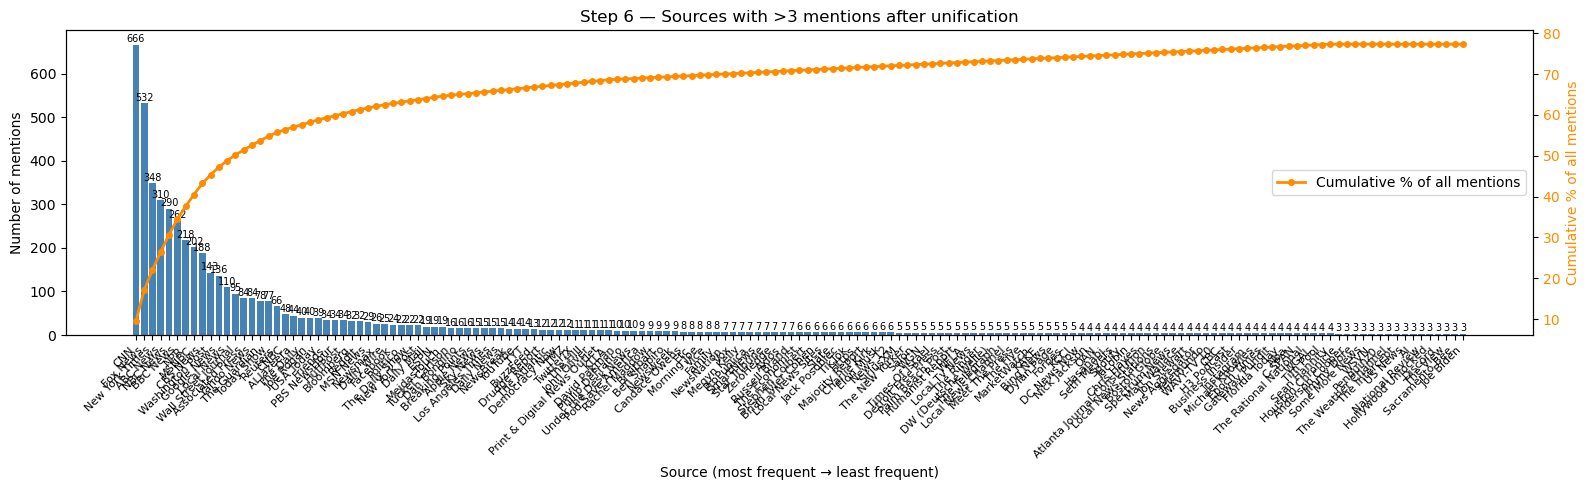

Total mentions after unification: 6975
  Top   1 sources cover 666 of 6975 mentions (9.5%)
  Top   5 sources cover 2146 of 6975 mentions (30.8%)
  Top  10 sources cover 3159 of 6975 mentions (45.3%)
  Top  20 sources cover 3981 of 6975 mentions (57.1%)
  Top  40 sources cover 4525 of 6975 mentions (64.9%)
  Top  80 sources cover 4937 of 6975 mentions (70.8%)
  Top 161 sources cover 5291 of 6975 mentions (75.9%)


In [16]:
# Distribution chart after Step 6 unification
total_mentions = unified_freq['count'].sum()
top_sources = unified_freq.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Step 6 — Sources with >3 mentions after unification')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step6.png', dpi=150)
plt.show()

print(f"Total mentions after unification: {total_mentions}")
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:3d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")


# Step 7: Frequency table and distribution chart after unification


In [17]:
unified_freq_final = unified_freq.copy()
unified_freq_final['cumulative_pct'] = (
    unified_freq_final['count'].cumsum() / unified_freq_final['count'].sum() * 100
).round(1)

top_unified_final = unified_freq_final[unified_freq_final['count'] > 3].copy()
print(f"Sources with >3 mentions after unification: {len(top_unified_final)}")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified_final.to_string())


Sources with >3 mentions after unification: 145

                           source  count  cumulative_pct
0                             CNN    666             9.5
1                        Fox News    532            17.2
2                  New York Times    348            22.2
3                        ABC News    310            26.6
4                        NBC News    290            30.8
5                        BBC News    262            34.5
6                             NPR    218            37.6
7                           MSNBC    202            40.5
8                        CBS News    188            43.2
9                 Washington Post    143            45.3
10                    Google News    136            47.2
11                     Local News    110            48.8
12            Wall Street Journal     95            50.2
13               Associated Press     84            51.4
14                     Yahoo News     84            52.6
15                   The Guardian     7

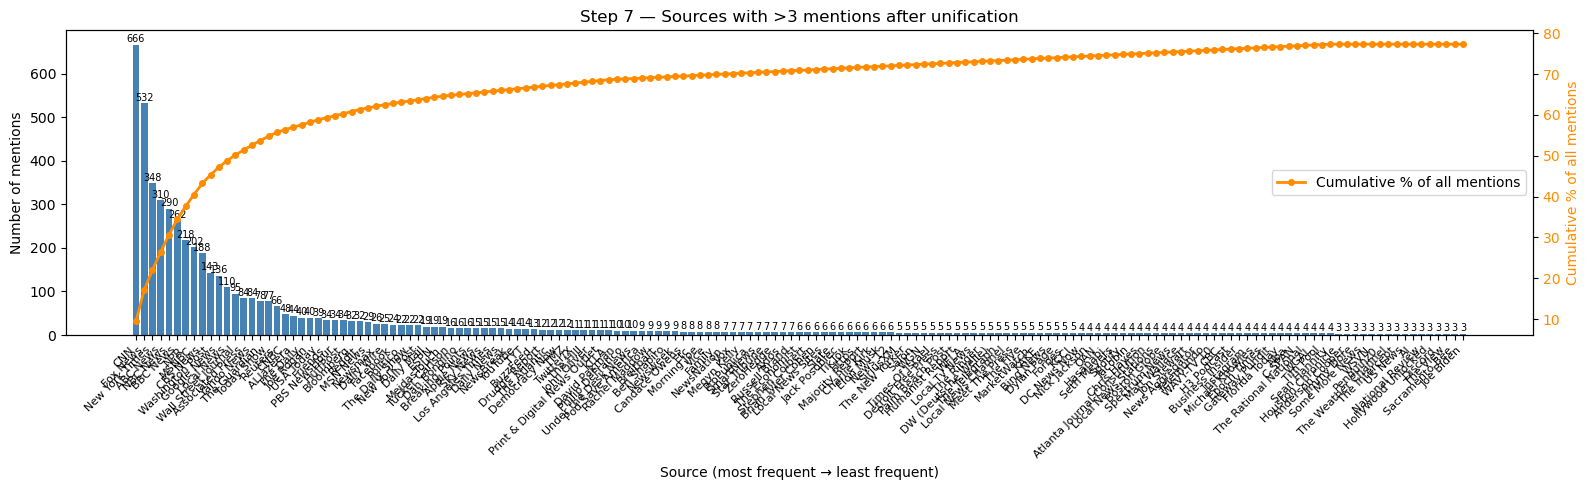

In [18]:
total_mentions_final = unified_freq_final['count'].sum()
top_sources = unified_freq_final.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions_final * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Step 7 — Sources with >3 mentions after unification')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step7.png', dpi=150)
plt.show()


# Step 8: Categorisation

Assign each unified source to one of 7 categories:

| Category | Examples |
|---|---|
| `National TV News Channel` | CNN, Fox News, MSNBC, BBC News, ABC News, NBC News |
| `Print & Digital News Outlet` | NYT, Washington Post, Reuters, AP, Breitbart, Daily Wire |
| `News Aggregator / App` | Google News, Apple News, Yahoo News, Flipboard, Ground News |
| `Radio and Podcasts` | NPR, Pod Save America, Democracy Now, Breaking Points; also numeric radio station IDs |
| `News + Entertainment` | John Oliver, Seth Meyers, The Daily Show, TYT, The View |
| `Social Media News Creator` | Penguinz0, Hasanabi, Tim Pool, Andy Ngo, Jordan Peterson |
| `Non-News / Local / Unclear` | TMZ, ESPN, Fox 13, The Shade Room, Google Discover, unresolved strings |

Sources whose string is clearly not a source name (noise that slipped through) go to `Non-News / Local / Unclear`.


In [19]:
import re

# Each entry: (exact source name, category)
# Order matters — first match wins.
# Note: 'National News Channel on Social Media' is assigned dynamically below
#       for any National News Channel source that appeared in an SM_col.

NATIONAL_TV = {
    'CNN', 'Fox News', 'MSNBC', 'ABC News', 'NBC News', 'CBS News',
    'PBS NewsHour', 'CNBC', 'NewsNation', 'Newsmax', 'Sky News', 'BBC News',
    'Al Jazeera', 'DW (Deutsche Welle)', 'CBC', 'Telemundo', 'Univision',
    'C-SPAN', 'WION', 'Voice of America', 'Spectrum News', 'The Weather Channel',
    'OAN', "Real America's Voice", 'Frontline', 'Today Show', 'Dateline NBC',
    'World News Tonight', 'Headline News',
}

CATEGORY_MAP = [
        ('Google News',           'News Aggregator / App'),
    ('Google Discover',       'News Aggregator / App'),
    ('Apple News',            'News Aggregator / App'),
    ('Yahoo News',            'News Aggregator / App'),
    ('MSN News',              'News Aggregator / App'),
    ('Flipboard',             'News Aggregator / App'),
    ('Ground News',           'News Aggregator / App'),
    ('NewsBreak',             'News Aggregator / App'),
    ('1440 Daily Digest',     'News Aggregator / App'),
    ('Drudge Report',         'News Aggregator / App'),
    ('RealClearPolitics',     'News Aggregator / App'),
    ('Haystack News',         'News Aggregator / App'),
    ('SmartNews',             'News Aggregator / App'),
    ('Bing News',             'News Aggregator / App'),
    ('PolitiFact',            'News Aggregator / App'),
    ('News Aggregator',       'News Aggregator / App'),

        # (SM_col appearances get 'National News Channel on Social Media' dynamically)
    ('CNN',             'National News Channel'),
    ('Fox News',        'National News Channel'),
    ('MSNBC',           'National News Channel'),
    ('ABC News',        'National News Channel'),
    ('NBC News',        'National News Channel'),
    ('CBS News',        'National News Channel'),
    ('PBS NewsHour',    'National News Channel'),
    ('CNBC',            'National News Channel'),
    ('NewsNation',      'National News Channel'),
    ('Newsmax',         'National News Channel'),
    ('Sky News',        'National News Channel'),
    ('BBC News',        'National News Channel'),
    ('Al Jazeera',      'National News Channel'),
    ('DW (Deutsche Welle)', 'National News Channel'),
    ('CBC',             'National News Channel'),
    ('Telemundo',       'National News Channel'),
    ('Univision',       'National News Channel'),
    ('C-SPAN',          'National News Channel'),
    ('WION',            'National News Channel'),
    ('Voice of America','National News Channel'),
    ('Spectrum News',   'National News Channel'),
    ('The Weather Channel', 'National News Channel'),
    ('OAN',             'National News Channel'),
    ("Real America's Voice", 'National News Channel'),
    ('Frontline',       'National News Channel'),
    ('Today Show',      'National News Channel'),
    ('Dateline NBC',    'National News Channel'),
    ('World News Tonight', 'National News Channel'),
    ('Headline News',   'National News Channel'),

        ('NPR',                   'Radio and Podcasts'),
    ('Pod Save America',      'Radio and Podcasts'),
    ('Breaking Points',       'Radio and Podcasts'),
    ('Democracy Now',         'Radio and Podcasts'),
    ('This American Life',    'Radio and Podcasts'),
    ('SiriusXM',              'Radio and Podcasts'),
    ('iHeartRadio',           'Radio and Podcasts'),
    ('Joe Rogan',             'Radio and Podcasts'),
    ('H3 Podcast',            'Radio and Podcasts'),
    ('PBD Podcast',           'Radio and Podcasts'),
    ('Freakonomics',          'Radio and Podcasts'),
    ('Morning Wire',          'Radio and Podcasts'),
    ('The Daily',             'Radio and Podcasts'),   # NYT daily news podcast
    ('WBUR',                  'Radio and Podcasts'),   # Boston NPR affiliate
    ('WNYC',                  'Radio and Podcasts'),   # NY public radio

        ('Local News',            'Local News'),
    ('Local News Sites',      'Local News'),
    ('Local News Channel',    'Local News'),
    ('Local News Stations',   'Local News'),
    ('Local Tv News',         'Local News'),
    ('Local Tv Channels',     'Local News'),
    ('Local Newspaper',       'Local News'),
    ('Local Radio Stations',  'Local News'),
    # Local newspapers
    ('Chicago Tribune',       'Local News'),
    ('Houston Chronicle',     'Local News'),
    ('Detroit Free Press',    'Local News'),
    ('Star Tribune',          'Local News'),
    ('Palm Beach Post',       'Local News'),
    ('Florida Today',         'Local News'),
    ('Newsday',               'Local News'),
    ('PennLive',              'Local News'),
    ('MassLive',              'Local News'),
    ('Orlando Sentinel',      'Local News'),
    ('Tampa Bay Times',       'Local News'),
    ('Dallas Morning News',   'Local News'),
    ('San Francisco Chronicle','Local News'),
    ('Arkansas Democrat-Gazette', 'Local News'),
    ('Green Bay Press-Gazette', 'Local News'),
    ('Jacksonville Daily Record', 'Local News'),
    ('Colorado Springs Gazette', 'Local News'),
    ('Denver Post',           'Local News'),
    ('Providence Journal',    'Local News'),
    ('Cincinnati Enquirer',   'Local News'),
    ('Columbus Dispatch',     'Local News'),
    ('Charlotte Observer',    'Local News'),
    ('San Diego Union-Tribune','Local News'),
    ('Kansas City Star',      'Local News'),
    ('Omaha World-Herald',    'Local News'),
    ('Philadelphia Inquirer', 'Local News'),
    ('Sacramento Bee',        'Local News'),
    ('Las Vegas Review-Journal','Local News'),
    ('Las Vegas Sun',         'Local News'),
    ('Indianapolis Star',     'Local News'),
    ('Buffalo News',          'Local News'),
    ('The Oregonian',         'Local News'),
    ('Boston Herald',         'Local News'),
    ('San Antonio Express-News', 'Local News'),
    ('Mercury News',          'Local News'),
    ('Pensacola News Journal','Local News'),
    ('Greenbrier News',       'Local News'),
    ('Atlanta Journal-Constitution', 'Local News'),
    ('Fox 13',                'Local News'),
    ('DC News Now',           'Local News'),
    ('News 12',               'Local News'),
    ('News On 6',             'Local News'),
    # Local TV call letters
    ('WBAL',  'Local News'), ('WBBM',  'Local News'), ('WFLA',  'Local News'),
    ('WFMZ',  'Local News'), ('WGAL',  'Local News'), ('WSVN',  'Local News'),
    ('WSFA',  'Local News'), ('WSB-TV','Local News'), ('WPLG',  'Local News'),
    ('KCCI',  'Local News'), ('KAKE',  'Local News'), ('KFYR',  'Local News'),
    ('KCRG',  'Local News'), ('KFVS',  'Local News'), ('KTLA',  'Local News'),
    ('KSL',   'Local News'), ('KARE 11','Local News'),('WKBN',  'Local News'),
    ('WAVY-TV 10','Local News'),('WXPN','Local News'),
    ('WCCO',  'Local News'), ('WESH',  'Local News'), ('WDRB',  'Local News'),
    ('WAFB',  'Local News'), ('KCAL',  'Local News'), ('PIX11', 'Local News'),
    ('WAVE 3','Local News'), ('WLKY',  'Local News'), ('KPTV',  'Local News'),
    ('WTOL',  'Local News'), ('WJHL',  'Local News'), ('WJZ',   'Local News'),
    ('WMAR',  'Local News'), ('WBAY',  'Local News'), ('WKRG',  'Local News'),
    ('WVLT',  'Local News'), ('WYMT',  'Local News'), ('WTAE',  'Local News'),
    ('WTAJ',  'Local News'), ('WISH',  'Local News'), ('WGRZ',  'Local News'),
    ('WRKO',  'Local News'), ('WDBO',  'Local News'), ('WNEP',  'Local News'),
    ('WLBT',  'Local News'), ('WBOC',  'Local News'), ('WTNH',  'Local News'),
    ('WFSB',  'Local News'), ('WVLA',  'Local News'), ('WBRZ',  'Local News'),
    ('WBRC',  'Local News'), ('WBEN',  'Local News'), ('WABC',  'Local News'),
    ('WWJ',   'Local News'), ('KOCO',  'Local News'), ('KGW',   'Local News'),
    ('KIRO',  'Local News'), ('KING TV','Local News'),('KHOU',  'Local News'),
    ('KATC',  'Local News'), ('KSAT',  'Local News'), ('KENS',  'Local News'),
    ('KBTX',  'Local News'), ('KTVZ',  'Local News'), ('KTEN',  'Local News'),
    ('KCRA',  'Local News'), ('KXAN',  'Local News'), ('KWQC',  'Local News'),
    ('KWWL',  'Local News'), ('KRGV',  'Local News'), ('KDKA',  'Local News'),
    ('KSTX',  'Local News'), ('WOAI',  'Local News'), ('KOTV',  'Local News'),
    ('KTNV',  'Local News'), ('RTV6',  'Local News'), ('WHO-TV','Local News'),
    ('NY1',   'Local News'), ('WITN',  'Local News'), ('WHNT',  'Local News'),
    ('WHIO',  'Local News'), ('WHEC',  'Local News'), ('WTHR',  'Local News'),
    ('WLTX',  'Local News'), ('WLOX',  'Local News'), ('WLNS',  'Local News'),
    ('WKYC',  'Local News'), ('WTOP',  'Local News'), ('WMAL',  'Local News'),
    ('WSON',  'Local News'), ('WPRO',  'Local News'), ('WNSC',  'Local News'),
    ('WIS',   'Local News'), ('WGN',   'Local News'),

        ('The Daily Show',        'News + Entertainment'),
    ('John Oliver',           'News + Entertainment'),
    ('Jon Stewart',           'News + Entertainment'),
    ('Seth Meyers',           'News + Entertainment'),
    ('TYT',                   'News + Entertainment'),
    ('Majority Report',       'News + Entertainment'),
    ('Secular Talk',          'News + Entertainment'),
    ('Some More News',        'News + Entertainment'),
    ('Under the Desk News',   'News + Entertainment'),
    ('The View',              'News + Entertainment'),
    ('MeidasTouch',           'News + Entertainment'),
    ('Occupy Democrats',      'News + Entertainment'),
    ('The Rational National', 'News + Entertainment'),
    ('Brian Tyler Cohen',     'News + Entertainment'),
    ('Humanist Report',       'News + Entertainment'),
    ('Morning Joe',           'National News Channel'),  # MSNBC morning news programme
    ('The Five',              'News + Entertainment'),
    ('Meet The Press',        'News + Entertainment'),
    ('Stephen Colbert',       'News + Entertainment'),
    ('Jimmy Dore',            'News + Entertainment'),
    ('Sam Seder',             'News + Entertainment'),
    ('The Ringer',            'News + Entertainment'),
    ('Bill Maher',            'News + Entertainment'),
    ('Jimmy Kimmel',          'News + Entertainment'),
    ('Inside Edition',        'News + Entertainment'),

        # SM-native or independent commentators — NOT primarily broadcast TV anchors
    ('Penguinz0',             'Social Media News Creator'),
    ('Hasanabi',              'Social Media News Creator'),
    ('Tim Pool',              'Social Media News Creator'),
    ('Mark Dice',             'Social Media News Creator'),
    ('Andy Ngo',              'Social Media News Creator'),
    ('Matt Walsh',            'Social Media News Creator'),
    ('Matt Wallace',          'Social Media News Creator'),
    ('Jordan Peterson',       'Social Media News Creator'),
    ('George Conway',         'Social Media News Creator'),
    ('Glenn Greenwald',       'Social Media News Creator'),
    ('Jonathan Turley',       'Social Media News Creator'),
    ('Beau of the Fifth Column', 'Social Media News Creator'),
    ('Redacted',              'Social Media News Creator'),
    ('Elon Musk',             'Social Media News Creator'),
    ('Tucker Carlson',        'Social Media News Creator'),  # left Fox, now SM-native
    ('Ben Shapiro',           'Social Media News Creator'),
    ('Rachel Maddow',         'National News Channel'),   # MSNBC anchor
    ('Megyn Kelly',           'Social Media News Creator'),  # left NBC, now SM-native
    ('Dan Bongino',           'Social Media News Creator'),
    ('David Pakman',          'Social Media News Creator'),
    ('Philip DeFranco',       'Social Media News Creator'),
    ('Jack Posobiec',         'Social Media News Creator'),
    ('Charlie Kirk',          'Social Media News Creator'),
    ('Michael Knowles',       'Social Media News Creator'),
    ('Mark Levin',            'Social Media News Creator'),
    ('Glenn Beck',            'Social Media News Creator'),
    ('Russell Brand',         'Social Media News Creator'),
    ('Candace Owens',         'Social Media News Creator'),
    ('Dylan Page',            'Social Media News Creator'),
    ('Nick Jackson',          'Social Media News Creator'),
    ('Sharonsaysso',          'Social Media News Creator'),
    ('Philip Lewis',          'Social Media News Creator'),
    # TV anchors who are primary faces of national channels
    ('Anderson Cooper',       'National News Channel'),   # CNN anchor
    ('Sean Hannity',          'National News Channel'),   # Fox News anchor
    ('Chris Hayes',           'National News Channel'),   # MSNBC anchor
    ('Ari Melber',            'National News Channel'),   # MSNBC anchor
    ('Laura Ingraham',        'National News Channel'),   # Fox News anchor
    ('Jesse Watters',         'National News Channel'),   # Fox News anchor
    ("Lawrence O'Donnell",    'National News Channel'),   # primary TV anchor

        ('New York Times',        'Print & Digital News Outlet'),
    ('Washington Post',       'Print & Digital News Outlet'),
    ('Wall Street Journal',   'Print & Digital News Outlet'),
    ('USA Today',             'Print & Digital News Outlet'),
    ('Los Angeles Times',     'Print & Digital News Outlet'),
    ('Boston Globe',          'Local News'),   # regional city paper, consistent with Star Tribune / Detroit Free Press
    ('New York Post',         'Print & Digital News Outlet'),
    ('Daily Mail',            'Print & Digital News Outlet'),
    ('The Guardian',          'Print & Digital News Outlet'),
    ('Financial Times',       'Print & Digital News Outlet'),
    ('The Economist',         'Print & Digital News Outlet'),
    ('TIME Magazine',         'Print & Digital News Outlet'),
    ('Newsweek',              'Print & Digital News Outlet'),
    ('Associated Press',      'Print & Digital News Outlet'),
    ('Reuters',               'Print & Digital News Outlet'),
    ('Bloomberg',             'Print & Digital News Outlet'),
    ('Axios',                 'Print & Digital News Outlet'),
    ('Politico',              'Print & Digital News Outlet'),
    ('The Hill',              'Print & Digital News Outlet'),
    ('Vox',                   'Print & Digital News Outlet'),
    ('The Atlantic',          'Print & Digital News Outlet'),
    ('The New Yorker',        'Print & Digital News Outlet'),
    ('HuffPost',              'Print & Digital News Outlet'),
    ('BuzzFeed',              'Print & Digital News Outlet'),
    ('Vice',                  'Print & Digital News Outlet'),
    ('Slate',                 'Print & Digital News Outlet'),
    ('Salon',                 'Print & Digital News Outlet'),
    ('ProPublica',            'Print & Digital News Outlet'),
    ('Forbes',                'Print & Digital News Outlet'),
    ('MarketWatch',           'Print & Digital News Outlet'),
    ('Breitbart',             'Print & Digital News Outlet'),
    ('Daily Wire',            'Print & Digital News Outlet'),
    ('The Blaze',             'Print & Digital News Outlet'),
    ('BlazeTV',               'Print & Digital News Outlet'),
    ('ZeroHedge',             'Print & Digital News Outlet'),
    ('BNO News',              'Print & Digital News Outlet'),
    ('The Telegraph',         'Print & Digital News Outlet'),
    ('National Review',       'Print & Digital News Outlet'),
    ('The Intercept',         'Print & Digital News Outlet'),
    ('Jacobin',               'Print & Digital News Outlet'),
    ('The Bulwark',           'Print & Digital News Outlet'),
    ('Business Insider',      'Print & Digital News Outlet'),
    ('Jerusalem Post',        'Print & Digital News Outlet'),
    ('Times Of Israel',       'Print & Digital News Outlet'),
    ('Middle East Eye',       'Print & Digital News Outlet'),
    ('Epoch Times',           'Print & Digital News Outlet'),
    ('Daily Mirror',          'Print & Digital News Outlet'),
    ('Snopes',                'Print & Digital News Outlet'),
    ('Daily Beast',           'Print & Digital News Outlet'),
    ('PinkNews',              'Print & Digital News Outlet'),
    ('New York Magazine',     'Print & Digital News Outlet'),
    ('The Independent',       'Print & Digital News Outlet'),
    ('Washington Examiner',   'Print & Digital News Outlet'),
    ('Ynet',                  'Print & Digital News Outlet'),
    ('Raw Story',             'Print & Digital News Outlet'),
    ('The Free Press',        'Print & Digital News Outlet'),
    ('Mediaite',              'Print & Digital News Outlet'),
    ('Alternet',              'Print & Digital News Outlet'),
    ('Christian Science Monitor', 'Print & Digital News Outlet'),
    ('Texas Tribune',         'Print & Digital News Outlet'),
    ('Daily Kos',             'Print & Digital News Outlet'),
    ('Political Wire',        'Print & Digital News Outlet'),
    ('Morning Wire',          'Print & Digital News Outlet'),
    ('Gateway Pundit',        'Print & Digital News Outlet'),
    ('UPI',                   'Print & Digital News Outlet'),
    ('Variety',               'Print & Digital News Outlet'),
    ('NY Daily News',         'Print & Digital News Outlet'),
    ('Daily News',            'Print & Digital News Outlet'),   # NY Daily News
    ('US News',               'Print & Digital News Outlet'),
    ('The Chronicle Of Higher Education', 'Print & Digital News Outlet'),
        # National News Channel
    ('i24News',                   'National News Channel'),
    ('AriseTv',                   'National News Channel'),
    # Local News
    ('Action News Jax',           'Local News'),
    ('Great Falls Tribune',       'Local News'),
    ('La Crosse Tribune',         'Local News'),
    ('Muscatine Journal',         'Local News'),
    ('Sarasota Herald-Tribune',   'Local News'),
    ('Statesman Journal',         'Local News'),
    ('WAPT News',                 'Local News'),
    ('WBKO News',                 'Local News'),
    ('13News Now',                'Local News'),
    ('Hemet Valley News',         'Local News'),
    ('Wane 15',                   'Local News'),
    ('WANE 15',                   'Local News'),
    # Radio and Podcasts
    ('South Carolina Public Radio', 'Radio and Podcasts'),
    ('Nevada Public Radio',       'Radio and Podcasts'),
    ('WTMJ Radio',                'Radio and Podcasts'),
    ('Radiolab',                  'Radio and Podcasts'),
    ('Ralph Nader Radio Hour',    'Radio and Podcasts'),
    ('Airone Radio',              'Radio and Podcasts'),
    ('Hal Turner Radio',          'Radio and Podcasts'),
    # Print & Digital
    ('Rocanews',                  'Print & Digital News Outlet'),
    ('Global News',               'Print & Digital News Outlet'),
    ('Disclose.tv',               'Print & Digital News Outlet'),
    ('Beverly Hills Courier',     'Print & Digital News Outlet'),
    ('The Brunswick News',        'Print & Digital News Outlet'),
    # Social Media News Creator
    ('Asmongold',                 'Social Media News Creator'),
    # Political communicator — closer to news source than entertainment
    ('Joe Biden',                 'Social Media News Creator'),

]

RADIO_NUMBER_PAT = re.compile(r'^\d{2,4}(\.\d)?$')

# Sources that map to a category string (used to block category names as sources)
_CAT_NAMES = {
    'Print & Digital News Outlet', 'National TV News Channel',
    'National News Channel', 'Local News', 'News + Entertainment',
    'Radio and Podcasts', 'News Aggregator / App', 'Social Media News Creator',
    'Non-News Related', 'Social Media Platform',
    'Local Channels', 'Local Newspapers', 'Local Television News',
    'National News Programs', 'National News Channels',
}

def categorise(source, is_sm_col=False):
    # Block category names appearing as sources
    if source in _CAT_NAMES:
        return 'Non-News Related'
    # Numeric radio station IDs
    if RADIO_NUMBER_PAT.match(source):
        return 'Radio and Podcasts'
    # Exact match
    for name, cat in CATEGORY_MAP:
        if source == name:
            # National News Channel sources written in SM columns → special category
            if cat == 'National News Channel' and is_sm_col:
                return 'National News Channel on Social Media'
            return cat
    return 'Non-News Related'

# Rebuild col_type aligned to all_extracted_step4 rows, then filter to non-NOISE
# all_cleaned → explode via step4_series → all_extracted_step4
# We replicate the same explode to get col_type per row of all_extracted_step4

col_type_per_cleaned = exploded['col_type'].reset_index(drop=True)

step4_lengths = all_cleaned.apply(lambda s: len(extract_frequent(s, candidate_names)))
col_type_step4_exploded = col_type_per_cleaned.repeat(step4_lengths).reset_index(drop=True)

# Filter to non-NOISE rows — same mask used to build unified_series_clean
noise_mask = (unified_series != 'NOISE').values
col_type_clean = col_type_step4_exploded[noise_mask].reset_index(drop=True)

# Build a per-mention DataFrame: source name + col_type
mention_df = pd.DataFrame({
    'source':   unified_series_clean.reset_index(drop=True),
    'col_type': col_type_clean,
})

# For each source, decide category using majority col_type:
# if the source appears more often in SM_col than MM_col → SM-aware categorise
def majority_col_type(group):
    counts = group['col_type'].value_counts()
    return counts.index[0]  # most common col_type for this source

source_col_type = mention_df.groupby('source').apply(majority_col_type)

# Apply categorise once per unique source (avoids length mismatch)
unified_freq_final['category'] = unified_freq_final['source'].map(
    lambda src: categorise(src, is_sm_col=(source_col_type.get(src, 'MM_col') == 'SM_col'))
)

print("=== Sources with >3 mentions — with categories ===")
display_cols = ['source', 'count', 'category']
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 50):
    display(unified_freq_final[unified_freq_final['count'] > 3][display_cols])

print("\n=== Category counts (all sources, any frequency) ===")
print(unified_freq_final['category'].value_counts().to_string())


=== Sources with >3 mentions — with categories ===


C:\Users\username\AppData\Local\Temp\ipykernel_9084\100420337.py:405: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_col_type = mention_df.groupby('source').apply(majority_col_type)


,source,count,category
0,CNN,666,National News Channel
1,Fox News,532,National News Channel
2,New York Times,348,Print & Digital News Outlet
3,ABC News,310,National News Channel
4,NBC News,290,National News Channel
5,BBC News,262,National News Channel on Social Media
6,NPR,218,Radio and Podcasts
7,MSNBC,202,National News Channel
8,CBS News,188,National News Channel
9,Washington Post,143,Print & Digital News Outlet



=== Category counts (all sources, any frequency) ===
category
Non-News Related                         1322
Local News                                151
Print & Digital News Outlet                71
Social Media News Creator                  32
National News Channel                      30
Radio and Podcasts                         29
News + Entertainment                       24
News Aggregator / App                      12
National News Channel on Social Media       9


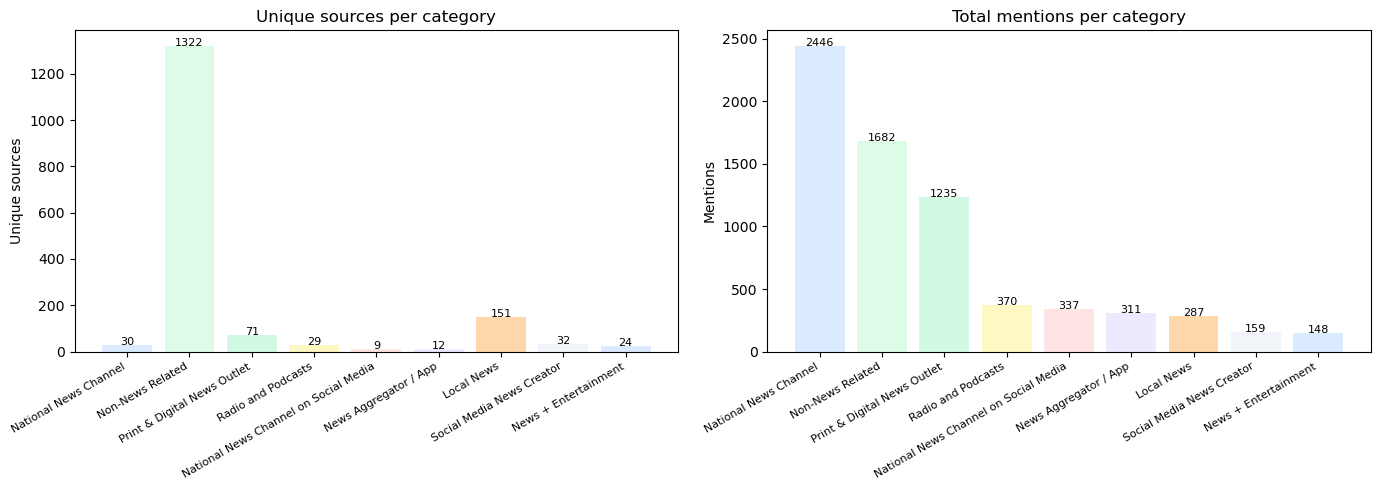

                             category  unique_sources  total_mentions
                National News Channel              30            2446
                     Non-News Related            1322            1682
          Print & Digital News Outlet              71            1235
                   Radio and Podcasts              29             370
National News Channel on Social Media               9             337
                News Aggregator / App              12             311
                           Local News             151             287
            Social Media News Creator              32             159
                 News + Entertainment              24             148


In [20]:
# Bar chart: number of unique sources per category
cat_counts = unified_freq_final.groupby('category').agg(
    unique_sources=('source', 'count'),
    total_mentions=('count', 'sum')
).sort_values('total_mentions', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = ['#DBEAFE','#DCFCE7','#D1FAE5','#FEF9C3','#FFE4E6','#EDE9FE','#FED7AA','#F1F5F9']

axes[0].bar(cat_counts['category'], cat_counts['unique_sources'],
            color=colours[:len(cat_counts)])
axes[0].set_title('Unique sources per category')
axes[0].set_ylabel('Unique sources')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
for i, v in enumerate(cat_counts['unique_sources']):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=8)

axes[1].bar(cat_counts['category'], cat_counts['total_mentions'],
            color=colours[:len(cat_counts)])
axes[1].set_title('Total mentions per category')
axes[1].set_ylabel('Mentions')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
for i, v in enumerate(cat_counts['total_mentions']):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('categories_step8.png', dpi=150)
plt.show()

print(cat_counts.to_string(index=False))


## Step 8b: Export categorisation to Excel

Creates `source_categories.xlsx` with one sheet per category — same layout as the reference spreadsheet sent to the professor.


In [21]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

CAT_COLOURS = {
    'National News Channel':                      'DBEAFE',
    'National News Channel on Social Media':      'BFDBFE',
    'Print & Digital News Outlet':                'DCFCE7',
    'News Aggregator / App':                      'D1FAE5',
    'Radio and Podcasts':                         'FEF9C3',
    'News + Entertainment':                       'FFE4E6',
    'Social Media News Creator':                  'EDE9FE',
    'Local News':                                 'E0F2FE',
    'Non-News Related':                           'F1F5F9',
}

thin = Side(style='thin', color='D0D0D0')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = Workbook()
wb.remove(wb.active) 
ws_all = wb.create_sheet('All Sources')
headers = ['Source', 'Category', 'Mentions']
widths  = [35, 32, 12]
for col, (h, w) in enumerate(zip(headers, widths), 1):
    c = ws_all.cell(row=1, column=col, value=h)
    c.font = Font(bold=True, size=11, color='FFFFFF', name='Arial')
    c.fill = PatternFill('solid', start_color='1E3A5F')
    c.alignment = Alignment(horizontal='center', vertical='center')
    c.border = border
    ws_all.column_dimensions[get_column_letter(col)].width = w
ws_all.row_dimensions[1].height = 28
ws_all.freeze_panes = 'A2'
ws_all.auto_filter.ref = f'A1:C{len(unified_freq_final)+1}'

for row_idx, row in enumerate(
    unified_freq_final[['source','category','count']]
    .sort_values(['category','count'], ascending=[True, False])
    .itertuples(index=False), start=2
):
    colour = CAT_COLOURS.get(row.category, 'FFFFFF')
    fill = PatternFill('solid', start_color=colour)
    for col, val in enumerate([row.source, row.category, row.count], 1):
        c = ws_all.cell(row=row_idx, column=col, value=val)
        c.fill = fill
        c.border = border
        c.font = Font(size=10, name='Arial')
        c.alignment = Alignment(vertical='top', wrap_text=col < 3)
        if col == 3:
            c.alignment = Alignment(horizontal='center', vertical='top')
 
wb.save('categories.xlsx')